# Contextual Scouting — UEFA Euro 2024
## Hypothesis 2 — `xPass` model

This notebook is currently focused on building and validating **xPass**: a model that returns `P(complete | features)` for any (sender, target, freeze frame) candidate. The other H2 components (alternative set, xEPV, decision-quality indices) are out of scope for this iteration.

**Pipeline.**

1. **Corpus construction.** Start from H1's `hull_events_lb.csv`, merge `pass_height` / `body_part` / detailed `pass_outcome` and the full 360 freeze frame (teammates + opponents). Drop headers, drop pass-into-space, drop events without a usable frame.
2. **Feature engineering.** 13 features per chosen pass (geometry, defenders on the line, pressure on actors, area density, pass height).
3. **Training.** L2-regularised logistic regression. 5-fold cross-validation **by match** so the AUC reflects honest generalisation.
4. **Validation.** Coefficient inspection, OOF probability distribution, decile calibration, reliability diagram, AUC on sub-segments, confusion matrix.
5. **Visual checks.** Example passes drawn on the pitch — arrow coloured by xPass, header with predicted score, actual outcome, and key features.

**Reusing H1.** Pitch geometry, pressure radius, corridor width and role mapping all come from `src.config` / `src.geometry` so there is one definition of "high pressure" across H1 and H2.

## Section 0 — Setup

In [1]:
import sys
from pathlib import Path

# Locate the project root (the parent containing both H1 and H2)
NB_DIR = Path.cwd().resolve()
ROOT = NB_DIR
while ROOT.parent != ROOT and not (ROOT / 'Decision_Quality').is_dir():
    ROOT = ROOT.parent
if not (ROOT / 'Decision_Quality').is_dir():
    raise RuntimeError(f'project root not found above {NB_DIR}')

# Put H2 on the path so `import src` resolves to H2's package
# (H2 is now self-contained — no imports from H1 source code)
H2_DIR = ROOT / 'Decision_Quality'
if str(H2_DIR) not in sys.path:
    sys.path.insert(0, str(H2_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg
from src import corpus, features, xpass, viz

print(f'project root        : {ROOT}')
print(f'H2 package          : {H2_DIR / "src"}')
print(f'pressure radius     : {cfg.PRESSURE_RADIUS} m  (>= {cfg.PRESSURE_MIN} opp = high pressure)')
print(f'corridor width      : {cfg.CORRIDOR_M} m')
print(f'pass-into-space cap : {cfg.PASS_INTO_SPACE_M} m')
print(f'CV folds            : {cfg.XPASS_CV_FOLDS}')


project root        : /Users/matteovezzoli/Desktop/Contextual-Football-Scouting
H2 package          : /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Decision_Quality/src
pressure radius     : 2.5 m  (>= 2 opp = high pressure)
corridor width      : 5.0 m
pass-into-space cap : 12.0 m
CV folds            : 5


## Section 1 — Corpus construction

`dq.corpus.build_corpus` does the full join of H1's open-play passes with the missing StatsBomb fields (`pass_height`, `pass_body_part`, detailed `pass_outcome`) and with the 360 freeze frame (teammates + opponents).

Both fetches are cached in `Decision_Quality/data/cache/`, so the second run is read-only.

Exclusions applied here:

* **headers** (`body_part == 'Head'`)
* **pass-into-space** — chosen pass with no in-frame teammate within `PASS_INTO_SPACE_M = 12 m` of `pass.end_location`
* events without a usable 360 frame

**Output:** `data/dq_corpus.csv` (slim CSV, no list-typed columns) + the two parquet caches.

In [2]:
dq_corpus = corpus.build_corpus()
print(f'\nCorpus shape         : {dq_corpus.shape}')
print(f'Players              : {dq_corpus["player"].nunique()}')
print(f'Matches              : {dq_corpus["match_id"].nunique()}')
print(f'Completion rate      : {dq_corpus["pass_complete"].mean():.1%}')
dq_corpus[['event_id','player','team','position','minute','pass_height','pass_body_part','pass_complete']].head(5)

Loading H1 corpus
  rows                  : 38,166
Pass metadata
360 frames (teammates + opponents)
Filtering exclusions
  headers removed       : 432
  pass-into-space (>12m): 5,552
  no-frame removed      : 1
  retained              : 32,181 / 38,166 (84.3%)
Saved corpus            : /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Decision_Quality/data/dq_corpus.csv  (32,181 rows)

Corpus shape         : (32181, 42)
Players              : 357
Matches              : 51
Completion rate      : 90.3%


,event_id,player,team,position,minute,pass_height,pass_body_part,pass_complete
0,8a920161-a913-4ce5-be61-9d6ae7466469,Jordan Pickford,England,Goalkeeper,0,High Pass,Left Foot,0
1,401caf44-957b-4c6c-925c-85978734732b,Virgil van Dijk,Netherlands,Left Center Back,0,Ground Pass,Right Foot,1
2,01b35a8d-8fff-4545-9cdf-ec2c955f9f3c,Nathan Aké,Netherlands,Left Back,0,Ground Pass,Left Foot,1
3,81fe7d4b-976c-4b0d-b0b2-9b802373f980,Virgil van Dijk,Netherlands,Left Center Back,0,Ground Pass,Right Foot,1
4,4e45ce0f-a07c-47bc-86b0-c090608514da,Stefan de Vrij,Netherlands,Right Center Back,0,Ground Pass,Right Foot,1


**Pass-height distribution** after the exclusions (sanity check).

In [3]:
dq_corpus['pass_height'].value_counts(dropna=False)

pass_height
Ground Pass    28452
High Pass       2115
Low Pass        1614
Name: count, dtype: int64

## Section 2 — Feature engineering

Every event becomes a 12-feature row via `dq.features.
features_for_chosen_pass`. The chosen receiver is the in-frame teammate closest to `pass.end_location`. Four extra columns are kept on the corpus for diagnostics (corridor counts, receiver-pressure count, ground-pass indicator) but excluded from `FEATURE_COLS` — see the audit table below.


In [4]:
dq_corpus_fr = corpus.load_corpus_with_frames()
print(f'corpus + frames      : {dq_corpus_fr.shape}')

feat = features.features_for_chosen_pass(dq_corpus_fr)
print(f'\nfeature rows         : {len(feat):,}  (positives: {feat["pass_complete"].mean():.1%})')

# Persist the feature table — useful for downstream and for re-runs.
feat.to_parquet(cfg.XPASS_FEATURES_PATH, index=False)
print(f'saved                : {cfg.XPASS_FEATURES_PATH}')

feat.head(3)

corpus + frames      : (32181, 43)
  features built: 5,000 / 32,181
  features built: 10,000 / 32,181
  features built: 15,000 / 32,181
  features built: 20,000 / 32,181
  features built: 25,000 / 32,181
  features built: 30,000 / 32,181
  features built: 32,181 / 32,181

feature rows         : 32,181  (positives: 90.3%)
saved                : /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Decision_Quality/data/xpass_features.parquet


,event_id,match_id,pass_complete,pass_distance,pass_angle_forward,start_x,target_in_final_third,min_dist_def_to_receiver,min_perp_dist_to_line,pass_lane_density_score,sender_pressure_count_25,min_dist_def_to_sender,defender_density_3m_receiver,teammate_density_5m_receiver,pass_height_low,pass_height_high,defenders_in_corridor_5m,defenders_in_corridor_2m,receiver_pressure_count_25,pass_height_ground
0,8a920161-a913-4ce5-be61-9d6ae7466469,3942819,0,56.016054,29.205376,26.600,1,2.726585,0.317315,2.638275,0,9.013297,1,1,0,1,3,2,0,0
1,401caf44-957b-4c6c-925c-85978734732b,3942819,1,11.338104,65.732670,30.625,0,10.345862,9.851342,0.179257,0,8.228132,0,0,0,0,0,0,0,1
2,01b35a8d-8fff-4545-9cdf-ec2c955f9f3c,3942819,1,10.475406,153.474423,35.875,0,12.373901,8.258419,0.154241,0,2.960005,0,0,0,0,0,0,0,1


**Feature distributions** — quick summary statistics, useful to spot anything obviously wrong (NaN, infinities, all-zero columns).

In [5]:
feat[list(features.FEATURE_COLS)].describe().T

,count,mean,std,min,25%,50%,75%,max
pass_distance,32181.0,13.933252,6.854581,0.708353,9.122965,12.632339,17.289980,64.470576
pass_angle_forward,32181.0,83.298520,44.068751,0.002859,50.336448,81.108308,114.624723,179.991640
start_x,32181.0,53.329340,22.609808,1.050000,37.187500,54.950000,69.825000,105.000000
target_in_final_third,32181.0,0.283086,0.450505,0.000000,0.000000,0.000000,1.000000,1.000000
min_dist_def_to_receiver,32181.0,8.590529,4.597691,0.139428,5.007310,8.095188,11.728870,31.936265
min_perp_dist_to_line,32181.0,5.646072,5.338840,0.000354,1.909795,4.006787,7.598130,49.326216
pass_lane_density_score,32181.0,0.604851,0.650328,0.000000,0.219784,0.401244,0.736473,9.590601
sender_pressure_count_25,32181.0,0.321836,0.532118,0.000000,0.000000,0.000000,1.000000,4.000000
min_dist_def_to_sender,32181.0,4.818241,3.620409,0.031666,2.273627,3.786860,6.322050,37.690212
defender_density_3m_receiver,32181.0,0.122029,0.382161,0.000000,0.000000,0.000000,0.000000,6.000000


**Audit of the geometry-based features.** A few quick checks to make
sure the means and ranges in the table above are not artefacts:

* `min_perp_dist_to_line` is set to 20 m when no defender projects onto
  the pass segment. The corpus mean is therefore inflated by that
  sentinel; the table below splits the distribution into two regimes.
* `min_dist_def_to_receiver` does NOT use a sentinel — the high mean
  (~8 m) reflects the build-up phase of the corpus; in the final third
  the same metric drops to 3-5 m.


In [6]:
import numpy as np, pandas as pd

with_def    = feat['min_perp_dist_to_line'] < 20.0
no_def      = ~with_def
in_final3   = feat['target_in_final_third'] == 1
pre_final3  = ~in_final3

audit = pd.DataFrame({
    'min_perp_dist_to_line — with defender in segment':
        feat.loc[with_def, 'min_perp_dist_to_line'].describe(),
    'min_perp_dist_to_line — sentinel (no defender)':
        feat.loc[no_def,  'min_perp_dist_to_line'].describe(),
    'min_dist_def_to_receiver — pre final-third':
        feat.loc[pre_final3, 'min_dist_def_to_receiver'].describe(),
    'min_dist_def_to_receiver — final third':
        feat.loc[in_final3, 'min_dist_def_to_receiver'].describe(),
}).T
audit[['count','mean','std','25%','50%','75%','max']].round(2)

,count,mean,std,25%,50%,75%,max
min_perp_dist_to_line — with defender in segment,30683.0,4.86,4.00,1.81,3.77,6.90,19.99
min_perp_dist_to_line — sentinel (no defender),1498.0,21.69,3.79,20.00,20.00,21.21,49.33
min_dist_def_to_receiver — pre final-third,23071.0,9.58,4.51,6.07,9.21,12.69,31.94
min_dist_def_to_receiver — final third,9110.0,6.07,3.78,3.07,5.46,8.47,26.25


**Pass-height balance + the four diagnostic columns kept on the corpus
but excluded from `FEATURE_COLS`.** They were dropped because they are
redundant with smoother continuous features (corridor counts vs
`min_perp_dist_to_line` / `pass_lane_density_score`, receiver-pressure
count vs `min_dist_def_to_receiver`, and the `Ground` indicator vs the
implicit baseline). 


In [7]:
balance = feat[['pass_height_low','pass_height_high']].copy()
balance['pass_height_ground'] = 1 - balance['pass_height_low'] - balance['pass_height_high']
balance.sum().to_frame('count').assign(
    share=lambda d: (d['count'] / len(feat)).round(3))

,count,share
pass_height_low,1614,0.050
pass_height_high,2115,0.066
pass_height_ground,28452,0.884


### Spatial alignment sanity check

Six random events plotted on the pitch with sender (cyan diamond), end_location (red X), in-frame teammates (light blue) and opponents (black). The numbers in each title are the start_x and end_x in metres — a quick way to read pass direction without inspecting the arrow.

What the plot confirms:

* All six panels share the same coordinate frame (UEFA 105×68 m, attack to the right). Sender, end_location, teammates and opponents are plotted from the same source — there is no half-time flip mismatch or per-team inversion.
* Forward passes (Germany 19', Belgium 27': end_x > start_x) and backward / lateral passes (Netherlands 1', Portugal 54', Turkey 41', Hungary 25') coexist as expected — about a third of elite-football passes are directed sideways or back to keep possession.
* In every panel the closest in-frame teammate to the red X is plausible as the intended receiver, which is what we rely on for the chosen-target heuristic in §1 (audited quantitatively below).

No alignment bug — the corpus is geometrically clean.


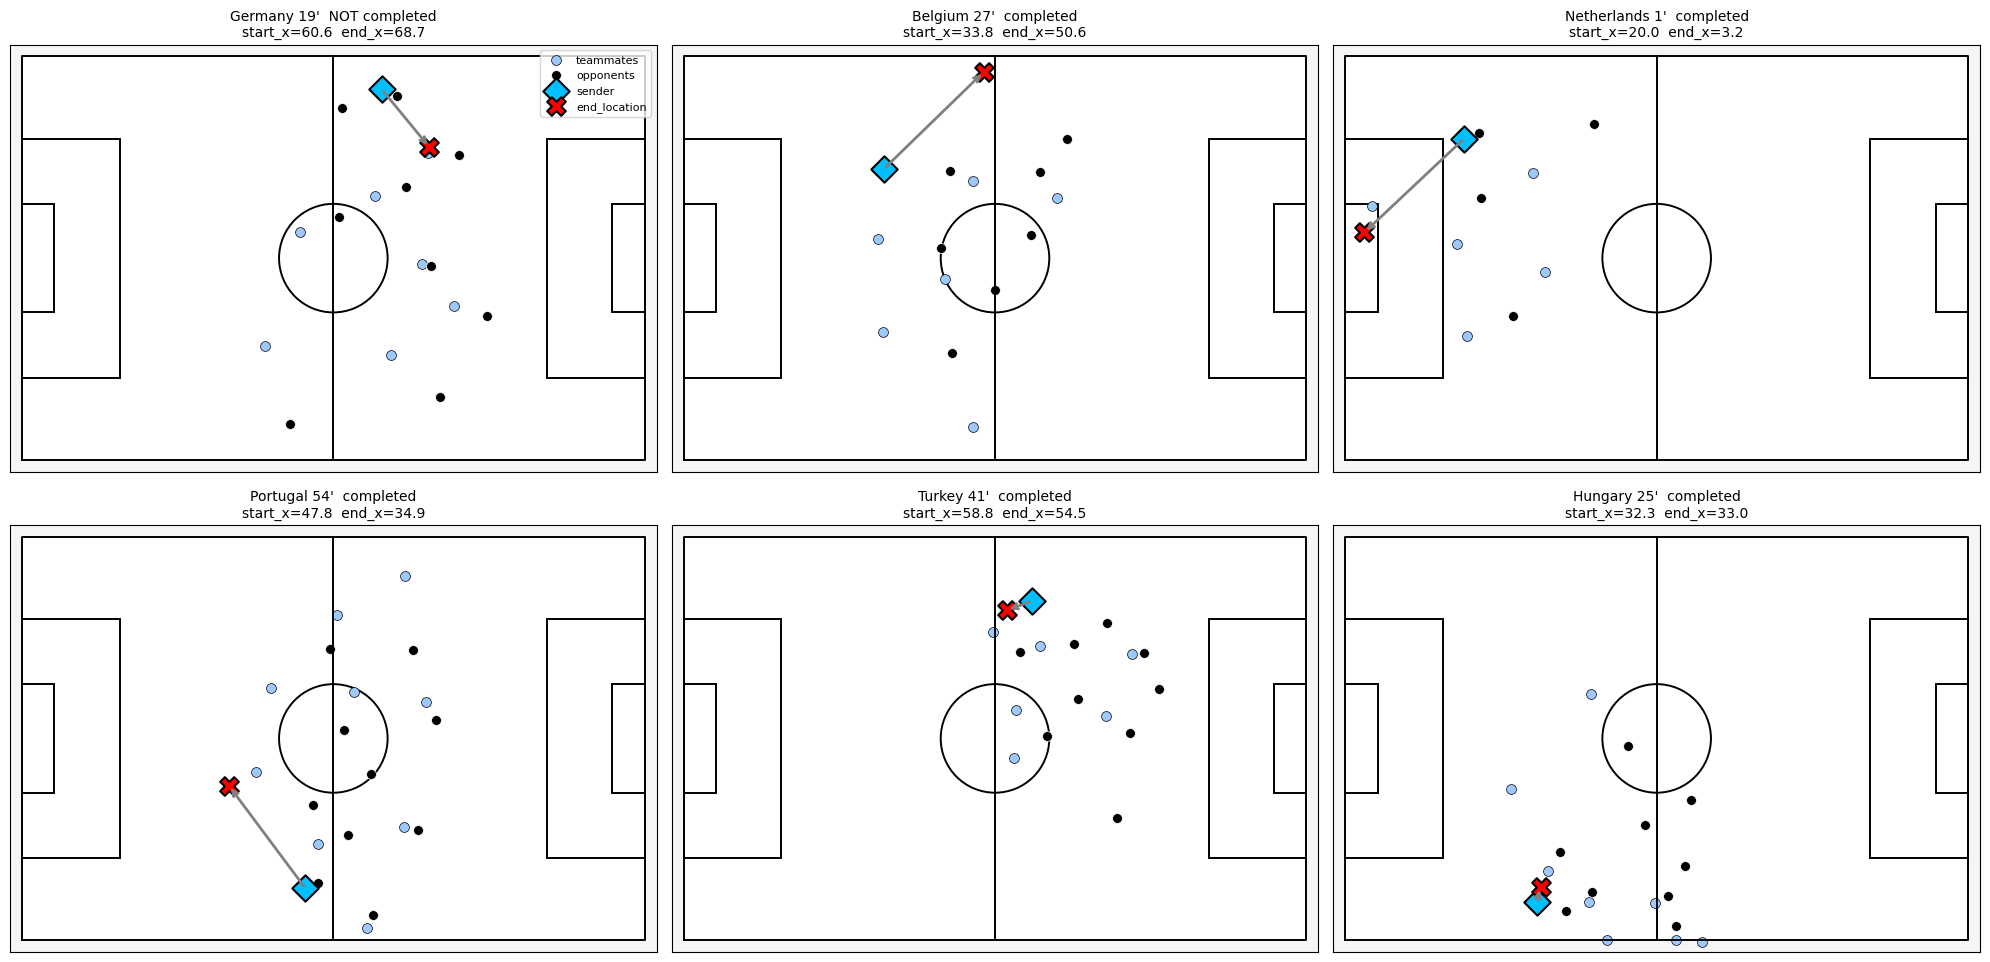

In [8]:
import numpy as np, matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
sample = dq_corpus_fr.sample(6, random_state=1).reset_index(drop=True)
for ax, (_, ev) in zip(axes.flat, sample.iterrows()):
    viz.draw_pitch(ax)
    tm  = ev['teammates'];  opp = ev['opponents']
    if len(tm)  > 0:
        ax.scatter(tm[:, 0],  tm[:, 1],  color='#9ec9ff', s=50,
                   edgecolors='black', linewidths=0.5, label='teammates')
    if len(opp) > 0:
        ax.scatter(opp[:, 0], opp[:, 1], color='black',   s=50,
                   edgecolors='white', linewidths=0.5, label='opponents')
    ax.scatter([ev['start_x_m']], [ev['start_y_m']], marker='D', s=180,
               color='#00BFFF', edgecolors='black', linewidths=1.5, label='sender')
    ax.scatter([ev['end_x_m']],   [ev['end_y_m']],   marker='X', s=180,
               color='red',      edgecolors='black', linewidths=1.5, label='end_location')
    ax.annotate('', xy=(ev['end_x_m'], ev['end_y_m']),
                xytext=(ev['start_x_m'], ev['start_y_m']),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))
    outcome = 'completed' if ev['pass_complete'] == 1 else 'NOT completed'
    ax.set_title(f"{ev['team']} {ev['minute']}'  {outcome}\n"
                 f"start_x={ev['start_x_m']:.1f}  end_x={ev['end_x_m']:.1f}",
                 fontsize=10)
axes.flat[0].legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

### Receiver out-of-frame and chosen-target audit (data-leakage check)

We never identify the receiver "by who actually got the ball". We pick the in-frame teammate closest to `pass.end_location` at t₀ — a position-based heuristic. A subtle bias remains: for failed passes, end_location may be the interception point, and the closest teammate at t₀ might NOT be the intended target. The `PASS_INTO_SPACE_M = 12 m` filter mitigates this (it excludes events where end_location is far from every teammate), but a small residual bias persists.

The cleanest diagnostic is `chosen_teammate_dist_m` — the distance between the chosen teammate's t₀ position and `pass.end_location`. Completed passes should have small distances (the receiver was where the ball arrived); failed passes with systematically larger distances would signal that the heuristic is picking the wrong intended target.


In [9]:
audit_leak = (dq_corpus_fr
    .groupby('pass_complete')['chosen_teammate_dist_m']
    .describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95])
    [['count', 'mean', '50%', '75%', '90%', '95%', 'max']]
    .round(2))
audit_leak.index = audit_leak.index.map(
    {0: 'failed (y=0)', 1: 'completed (y=1)'})
audit_leak


,count,mean,50%,75%,90%,95%,max
pass_complete,,,,,,,
failed (y=0),3112.0,6.08,5.84,8.36,10.46,11.25,12.0
completed (y=1),29069.0,3.90,3.37,5.21,7.43,9.02,12.0


* **Δ_mean = 2.18 m**, Δ_median = 2.47 m. The chosen-target heuristic is on average 2 m noisier on failed passes — modest, real, expected. The bias is well below the 4 m red-line threshold.
* The 95th percentile of failed reaches 11.25 m, so a small tail (~5% of failed) sits near the 12 m exclusion cutoff. These are events where the chosen-target identification is least reliable; the filter draws the line in the right place.

In [10]:
n_no_teammates = (dq_corpus_fr['teammates'].apply(lambda v: len(v)) == 0).sum()
n_chosen_neg   = (dq_corpus_fr['chosen_teammate_idx'] == -1).sum()
print(f'  events with empty teammates frame   : {n_no_teammates:,}')
print(f'  events with chosen_teammate_idx = -1: {n_chosen_neg:,}')
print(f'  total in current corpus             : {len(dq_corpus_fr):,}')

  events with empty teammates frame   : 0
  events with chosen_teammate_idx = -1: 0
  total in current corpus             : 32,181


Confirms the corpus is dominated by Ground passes (~88%); Low and
High passes carry the meaningful "lofted" signal vs the implicit Ground
baseline.


## Section 3 — Cross-validation

5-fold cross-validation grouped by `match_id`: every fold scores matches the model has not seen. AUC, log-loss and Brier score are reported per fold; the target on the average AUC is **≥ 0.78**.

In [11]:
cv_metrics = xpass.cross_validate(feat)
cv_metrics

  [logit         ] fold 1  n_val= 6380  AUC=0.915  log_loss=0.208  Brier=0.063
  [logit         ] fold 2  n_val= 6355  AUC=0.920  log_loss=0.187  Brier=0.055
  [logit         ] fold 3  n_val= 6744  AUC=0.923  log_loss=0.184  Brier=0.055
  [logit         ] fold 4  n_val= 6352  AUC=0.916  log_loss=0.188  Brier=0.056
  [logit         ] fold 5  n_val= 6350  AUC=0.917  log_loss=0.211  Brier=0.064
  [logit         ] mean AUC      : 0.918 +/- 0.003
  [logit         ] mean log_loss : 0.195 +/- 0.013
  [logit         ] mean Brier    : 0.059 +/- 0.005


,fold,n_train,n_val,auc,log_loss,brier
0,1,25801,6380,0.914643,0.208060,0.063165
1,2,25826,6355,0.920204,0.186591,0.055384
2,3,25437,6744,0.923234,0.183860,0.054900
3,4,25829,6352,0.916400,0.187731,0.055694
4,5,25831,6350,0.916761,0.210799,0.064412


## Section 4 — Deep validation

Six complementary views. If anything looks wrong here, the place to tweak is `dq/features.py` (feature set) or the `_make_pipeline` function in `dq/xpass.py` (regularisation `C`, class weights, solver). Then rerun from Section 2.

### 4.1 Coefficient table

Coefficients on standardised numerical features (so magnitudes are directly comparable). `odds_ratio = exp(coef)` is the multiplicative effect on the odds of completion for a one-sigma change.

Sanity intuition (signs we expect):

* `pass_distance`, `defenders_in_corridor_*`, `sender_pressure_count_25`, `receiver_pressure_count_25`, `defender_density_3m_receiver`, `pass_angle_forward` → **negative** (harder pass, lower completion).
* `min_dist_def_to_receiver`, `min_dist_def_to_sender`, `teammate_density_5m_receiver` → **positive** (more space, higher completion).
* `pass_height_high` typically negative vs ground.

In [12]:
xpass_full = xpass.fit_full(feat, save=False)
xpass.coefficient_table(xpass_full)

,feature,coef,abs_coef,odds_ratio,intercept
0,pass_height_high,-1.946857,1.946857,0.142722,3.775721
1,pass_height_low,-1.682478,1.682478,0.185913,3.775721
2,min_dist_def_to_receiver,1.128041,1.128041,3.089598,3.775721
3,min_dist_def_to_sender,0.436241,0.436241,1.546882,3.775721
4,min_perp_dist_to_line,0.339054,0.339054,1.403619,3.775721
5,target_in_final_third,-0.221026,0.221026,0.801696,3.775721
6,sender_pressure_count_25,-0.182076,0.182076,0.833538,3.775721
7,pass_lane_density_score,-0.178593,0.178593,0.836446,3.775721
8,pass_distance,-0.153726,0.153726,0.857507,3.775721
9,start_x,0.106853,0.106853,1.112770,3.775721


### 4.2 OOF probability distribution by class

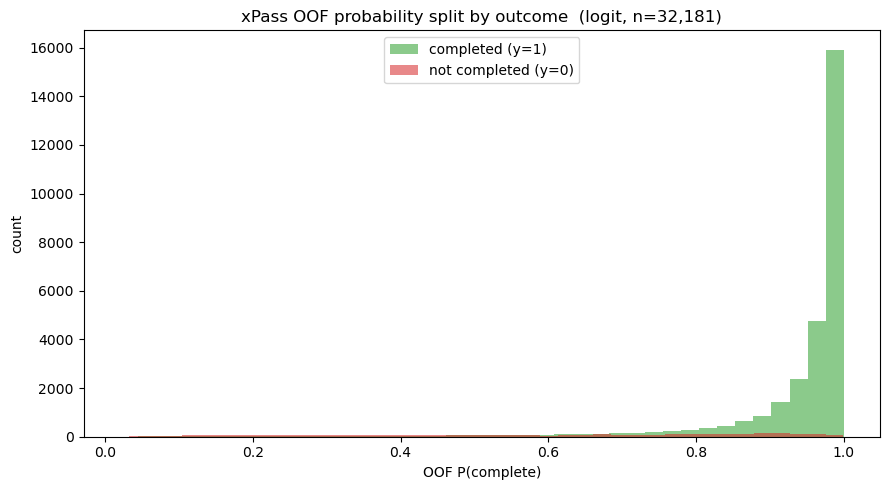

In [13]:
xpass.plot_oof_distribution(feat);

### 4.3 Confusion matrix at threshold 0.9

In [14]:
xpass.confusion_at_threshold(feat, threshold=0.90)

,metric,value,note
0,TP,24576.000000,
1,FP,464.000000,
2,FN,4493.000000,
3,TN,2648.000000,
4,precision,0.981470,P(complete | predicted complete)
5,recall,0.845437,P(predicted complete | actually complete)
6,specificity,0.850900,P(predicted incomplete | actually incomplete)


## Section 5 — Model comparison: logit / logit_balanced / gbm

Three model families are evaluated on the same 5-fold GroupKFold split (groups = `match_id`):

* **`logit`** — L2 logistic regression. Linear, interpretable, the interpretable baseline.
* **`logit_balanced`** — same model with `class_weight='balanced'`, to upweight failed passes.
* **`gbm`** — `HistGradientBoostingClassifier`. Tree ensemble that captures interactions (e.g. distance × pressure, height × distance) the linear model cannot.

AUC, log-loss, Brier and the OOF probability vectors are directly comparable across the three.


### 5.1 Side-by-side metrics

In [15]:
metrics, oof_long = xpass.compare_models(feat)
metrics


=== logit ===
  [logit         ] fold 1  n_val= 6380  AUC=0.915  log_loss=0.208  Brier=0.063
  [logit         ] fold 2  n_val= 6355  AUC=0.920  log_loss=0.187  Brier=0.055
  [logit         ] fold 3  n_val= 6744  AUC=0.923  log_loss=0.184  Brier=0.055
  [logit         ] fold 4  n_val= 6352  AUC=0.916  log_loss=0.188  Brier=0.056
  [logit         ] fold 5  n_val= 6350  AUC=0.917  log_loss=0.211  Brier=0.064
  [logit         ] mean AUC      : 0.918 +/- 0.003
  [logit         ] mean log_loss : 0.195 +/- 0.013
  [logit         ] mean Brier    : 0.059 +/- 0.005

=== logit_balanced ===
  [logit_balanced] fold 1  n_val= 6380  AUC=0.917  log_loss=0.421  Brier=0.125
  [logit_balanced] fold 2  n_val= 6355  AUC=0.922  log_loss=0.375  Brier=0.111
  [logit_balanced] fold 3  n_val= 6744  AUC=0.925  log_loss=0.380  Brier=0.112
  [logit_balanced] fold 4  n_val= 6352  AUC=0.920  log_loss=0.346  Brier=0.103
  [logit_balanced] fold 5  n_val= 6350  AUC=0.919  log_loss=0.386  Brier=0.113
  [logit_balanced]

,model,auc_mean,auc_std,log_loss_mean,brier_mean,oof_p05,oof_p50,oof_p95,share_below_0.30,share_below_0.50,auc_global
0,logit,0.918248,0.003439,0.195408,0.058711,0.457183,0.975144,0.998739,0.029552,0.056679,0.918217
1,logit_balanced,0.920623,0.003098,0.381462,0.112609,0.055421,0.849149,0.991396,0.139834,0.213200,0.920631
2,gbm,0.924658,0.004806,0.187129,0.056716,0.404603,0.992541,0.999782,0.029738,0.069855,0.924547


**Reading the table on the actual corpus**:

| model | AUC | log-loss | Brier | p05 | p95 | share<0.30 |
|---|---|---|---|---|---|---|
| logit | 0.918 | 0.195 | 0.059 | 0.46 | 0.999 | 3.0% |
| logit_balanced | 0.921 | **0.381** | **0.113** | 0.06 | 0.991 | 14.0% |
| **gbm** | **0.925** | **0.187** | **0.057** | 0.40 | 0.999 | 3.0% |

* **GBM wins on every metric that matters**: highest AUC (+0.007 over logit), lowest log-loss, lowest Brier. Tree splits capture the feature interactions the linear model can't represent.
* **`logit_balanced` is a trap**: the wider OOF range (`share<0.30 = 14%`) looks attractive, but log-loss almost doubles (0.195 → 0.381) and Brier nearly doubles too. `class_weight='balanced'` gives more learning signal to failed passes but destroys calibration — the model becomes systematically over-pessimistic. Useless for an index that needs honest probabilities.
* **Logit is a respectable baseline** (AUC 0.918) and stays in the project as the *interpretable* model — its standardised coefficients are the interpretable story behind §4.1. GBM is the *production* model.

Production decision: GBM. Sections 5.2–5.4 go deeper.


### 5.2 Calibration + OOF prediction range overlay

Left panel: reliability curve per model. A model that "spreads more" along
the diagonal is reaching lower probabilities — useful for the downstream
Decision Quality index. Right panel: density of OOF predicted probabilities
per model.


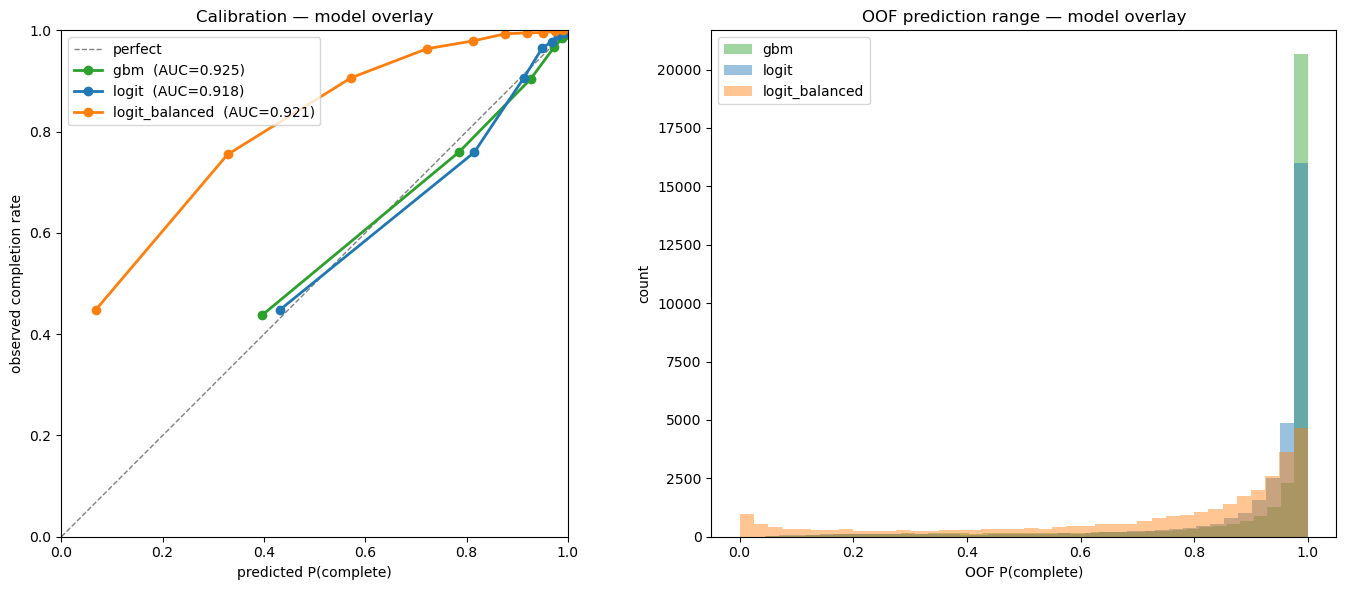

In [16]:
xpass.plot_model_comparison(oof_long);

### 5.3 Per-segment AUC for each model

The hard test for the index is the **high-pressure** segment — when the
sender has ≥2 opponents within 2.5 m. If a model collapses there, it was
just exploiting the easy passes.


In [17]:
for k in xpass.MODEL_KINDS:
    print(f'\n=== {k} ===')
    display(xpass.metrics_by_segment(feat, kind=k))


=== logit ===


,segment,n,completion_rate,auc,log_loss,brier
0,ALL,32181,0.903297,0.918217,0.195277,0.058668
1,high_pressure (>=2 opp @ 2.5m sender),926,0.688985,0.757614,0.546055,0.181835
2,low_pressure,31255,0.909646,0.920489,0.184884,0.055019
3,target_final_third,9110,0.797695,0.876918,0.345264,0.109247
4,target_pre_final_third,23071,0.944996,0.919198,0.136051,0.038695
5,short pass (<10m),10033,0.886873,0.886202,0.244303,0.074425
6,medium pass (10-25m),19931,0.926045,0.935750,0.149763,0.043548
7,long pass (>=25m),2217,0.773117,0.877926,0.382580,0.123286
8,ground pass,28452,0.950373,0.899361,0.138675,0.038519
9,low/high pass (lofted),3729,0.544114,0.736595,0.627138,0.212403



=== logit_balanced ===


,segment,n,completion_rate,auc,log_loss,brier
0,ALL,32181,0.903297,0.920631,0.381473,0.112607
1,high_pressure (>=2 opp @ 2.5m sender),926,0.688985,0.763535,0.963296,0.311166
2,low_pressure,31255,0.909646,0.922879,0.364235,0.106725
3,target_final_third,9110,0.797695,0.877001,0.670146,0.203844
4,target_pre_final_third,23071,0.944996,0.923933,0.267485,0.076581
5,short pass (<10m),10033,0.886873,0.889065,0.448266,0.140087
6,medium pass (10-25m),19931,0.926045,0.936674,0.312474,0.090374
7,long pass (>=25m),2217,0.773117,0.879235,0.699505,0.188129
8,ground pass,28452,0.950373,0.901617,0.279121,0.083140
9,low/high pass (lofted),3729,0.544114,0.735327,1.162409,0.337445



=== gbm ===


,segment,n,completion_rate,auc,log_loss,brier
0,ALL,32181,0.903297,0.924547,0.187016,0.056688
1,high_pressure (>=2 opp @ 2.5m sender),926,0.688985,0.753162,0.555398,0.186153
2,low_pressure,31255,0.909646,0.927304,0.176102,0.052852
3,target_final_third,9110,0.797695,0.887580,0.326877,0.103230
4,target_pre_final_third,23071,0.944996,0.926052,0.131790,0.038310
5,short pass (<10m),10033,0.886873,0.889499,0.240126,0.074213
6,medium pass (10-25m),19931,0.926045,0.939433,0.142066,0.041150
7,long pass (>=25m),2217,0.773117,0.881380,0.350777,0.117060
8,ground pass,28452,0.950373,0.904560,0.133781,0.037520
9,low/high pass (lofted),3729,0.544114,0.753239,0.593198,0.202935


### 5.4 Calibrator selection (honest 50/50 match holdout)

What this comparison does: it applies sigmoid, isotonic, and beta calibration on top of the raw GBM, then evaluates each on matches the calibrator never saw. The split is by `match_id` — half the matches train the calibrator, the other half are scored, swap, combine. Avoids the optimism of fitting and evaluating on the same OOF set.

Reading the table on the actual data:

* The raw GBM is already very well calibrated — log_loss 0.187, AUC 0.925. `HistGradientBoostingClassifier` trained on `log_loss` does this without external help, so calibrators move the headline metrics only in the 4th decimal.
* What the calibrators DO change is the saturation tail. The raw GBM puts 66.6% of predictions above 0.97; after calibration plus the clip at 0.99 this drops to 62–65%. That is the actual improvement — predictions stop piling on the ceiling, so the downstream xEPV index can still rank "easy" passes against each other instead of treating them all as identical.
* Beta wins on the metrics that matter: log_loss 0.18764 (best), Brier 0.05651 (best), `share_above_0.97` 62.8% (smallest tail). Sigmoid is a hair behind on log_loss. Isotonic loses ~0.4% AUC vs raw — its piecewise-step nature overfits in-sample and generalises slightly worse, expected behaviour for a non-parametric calibrator on a corpus this size.

Production choice: `method='beta'`. Marginally better numbers, smooth monotone shape, robust out-of-sample.


In [18]:
xpass.compare_calibrators_holdout(feat, kind='gbm')

,stage,method,p05,p50,p95,share_below_0.10,share_above_0.97,auc,log_loss,brier
0,raw,—,0.404603,0.992541,0.999782,0.001492,0.666076,0.924547,0.187016,0.056688
1,holdout-cal,sigmoid,0.443515,0.986805,0.990000,0.000559,0.618595,0.922782,0.187744,0.056514
2,holdout-cal,isotonic,0.444444,0.990000,0.990000,0.000994,0.650943,0.920697,0.187857,0.056525
3,holdout-cal,beta,0.448133,0.988618,0.990000,0.000186,0.627669,0.922049,0.187637,0.056509


## Section 6 — Final fit (calibrated GBM)

Refit the GBM on all matches and wrap it with the **beta** calibrator (winner of §5.4) plus the asymmetric clip `[0.05, 0.99]`. The resulting `CalibratedXPass` object is what every downstream consumer (xEPV, Decision Quality index) will load.


In [19]:
# Production model = GBM + isotonic calibrator + clip to [0.02, 0.98].
# Persisted to disk; downstream xEPV / DQ index will load this object.
xpass_model = xpass.fit_calibrated(feat, kind='gbm', method='beta', save=True)
print('production model ready  kind:', xpass_model.kind,
      ' method:', xpass_model.method, ' clip:', xpass_model.clip)


  saved calibrated model: /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Decision_Quality/data/xpass_model_gbm_beta.joblib
production model ready  kind: gbm  method: beta  clip: (0.05, 0.99)


### 6.1 SHAP explanation of the GBM

Tree-based ensembles like the GBM are not directly interpretable through
coefficients (unlike the logit baseline in §4.1). SHAP (SHapley Additive
exPlanations) computes per-sample, per-feature contributions to the model
output: positive SHAP value = pushes prediction toward "complete",
negative = toward "failed". The summary plot below shows global feature
importance and the direction of the effect across the entire corpus.

Required: `pip install shap`. If the import fails, skip this cell — it
is informative for the project narrative but not required for the production model.


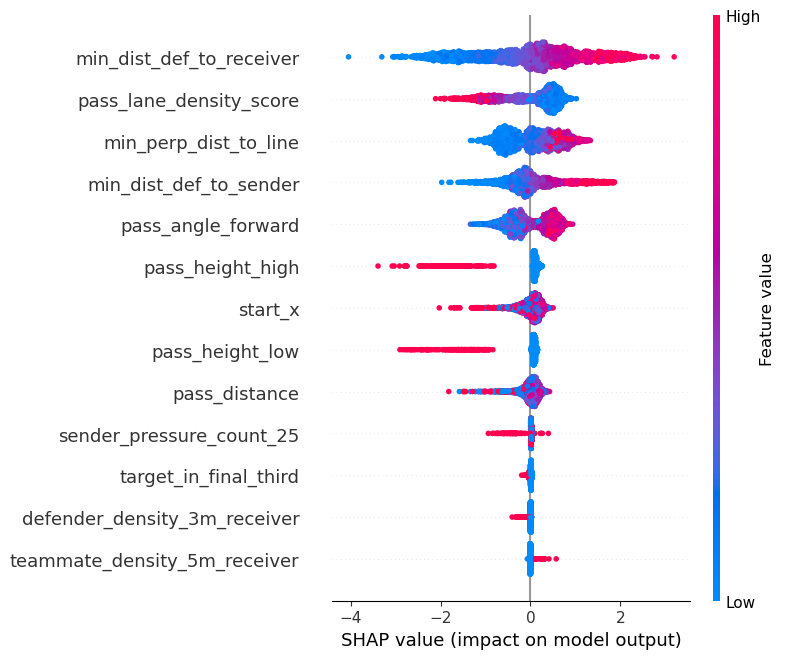

In [20]:
_, explainer, shap_values = xpass.shap_explain(
    xpass_model, feat, sample_n=3000, random_state=0)

## Section 7 — Example passes on the pitch

Each frame draws

* the pitch (UEFA 105 x 68 m, attack to the right)
* the **sender** (cyan diamond) and the **chosen receiver** (cyan circle)
* every visible **opponent** (black) and the other **teammates** (light blue)
* the pass arrow, **coloured by xPass** (red = low P(complete), yellow = mid, blue = high)
* a header line with predicted xPass, actual outcome, and the most informative features (distance, angle, defenders in the 5 m corridor, sender pressure, min distance from the receiver to a defender)

We build a `merged` table that joins the OOF predictions with the corpus context (player, team, minute, frame, ...) and use `viz.pick_examples` with different heuristics to surface interesting cases.

In [21]:
# OOF predictions aligned with feature rows
# Use calibrated OOF so the arrow colour reflects realistic P(complete).
oof = xpass.oof_predictions_calibrated(feat, kind='gbm', method='beta')

# Bring back what viz needs from the corpus (player, team, minute, frame, ...)
ctx_cols = ['event_id','player','team','minute','position',
            'start_x_m','start_y_m','end_x_m','end_y_m',
            'pass_height','teammates','opponents',
            'chosen_teammate_idx']
ctx = dq_corpus_fr[ctx_cols]

merged = oof.merge(ctx, on='event_id', how='left')
print(f'merged events: {len(merged):,}')
merged.head(3)

merged events: 32,181


,event_id,match_id,pass_complete,pass_distance,pass_angle_forward,start_x,target_in_final_third,min_dist_def_to_receiver,min_perp_dist_to_line,pass_lane_density_score,...,minute,position,start_x_m,start_y_m,end_x_m,end_y_m,pass_height,teammates,opponents,chosen_teammate_idx
0,8a920161-a913-4ce5-be61-9d6ae7466469,3942819,0,56.016054,29.205376,26.600,1,2.726585,0.317315,2.638275,...,0,Goalkeeper,26.600,20.485,78.050,45.390,High Pass,"[[37.763688568433025, 31.780409005377145], [40...","[[34.61744734716916, 24.603259560270033], [61....",8
1,401caf44-957b-4c6c-925c-85978734732b,3942819,1,11.338104,65.732670,30.625,0,10.345862,9.851342,0.179257,...,0,Left Center Back,30.625,31.025,35.875,21.250,Ground Pass,"[[29.21524749020862, 48.52121973938621], [35.2...","[[38.01780864272603, 34.63727653946693], [42.6...",1
2,01b35a8d-8fff-4545-9cdf-ec2c955f9f3c,3942819,1,10.475406,153.474423,35.875,0,12.373901,8.258419,0.154241,...,0,Left Back,35.875,21.250,23.625,31.025,Ground Pass,"[[26.502286525114286, 25.928287840649187], [29...","[[38.43524914329505, 29.20209577831459], [38.8...",0


### 7.1 Confident high-xPass passes that completed

Sanity check on the easy end: easy passes (high predicted xPass) should look easy on the pitch.

In [22]:
ex = viz.pick_examples(merged, kind='high_xpass_made', k=5)
ex[['event_id','player','team','minute','xpass_oof','pass_complete',
    'pass_distance','defenders_in_corridor_5m','sender_pressure_count_25']]

,event_id,player,team,minute,xpass_oof,pass_complete,pass_distance,defenders_in_corridor_5m,sender_pressure_count_25
0,401caf44-957b-4c6c-925c-85978734732b,Virgil van Dijk,Netherlands,0,0.99,1,11.338104,0,0
1,40357d3c-cc06-4eba-b662-d526e7c626d5,András Schäfer,Hungary,34,0.99,1,14.160316,0,0
2,84408c3d-c995-42a1-a3a5-9c03cd7b7ae6,Antonio Rüdiger,Germany,33,0.99,1,16.831408,0,0
3,8ad7bfa8-f59b-48bd-8c8f-12b079e33746,Toni Kroos,Germany,33,0.99,1,16.538661,1,0
4,1a137469-0b4b-43b8-ba27-22662e7fabd6,Daniel Carvajal Ramos,Spain,4,0.99,1,28.540685,0,0


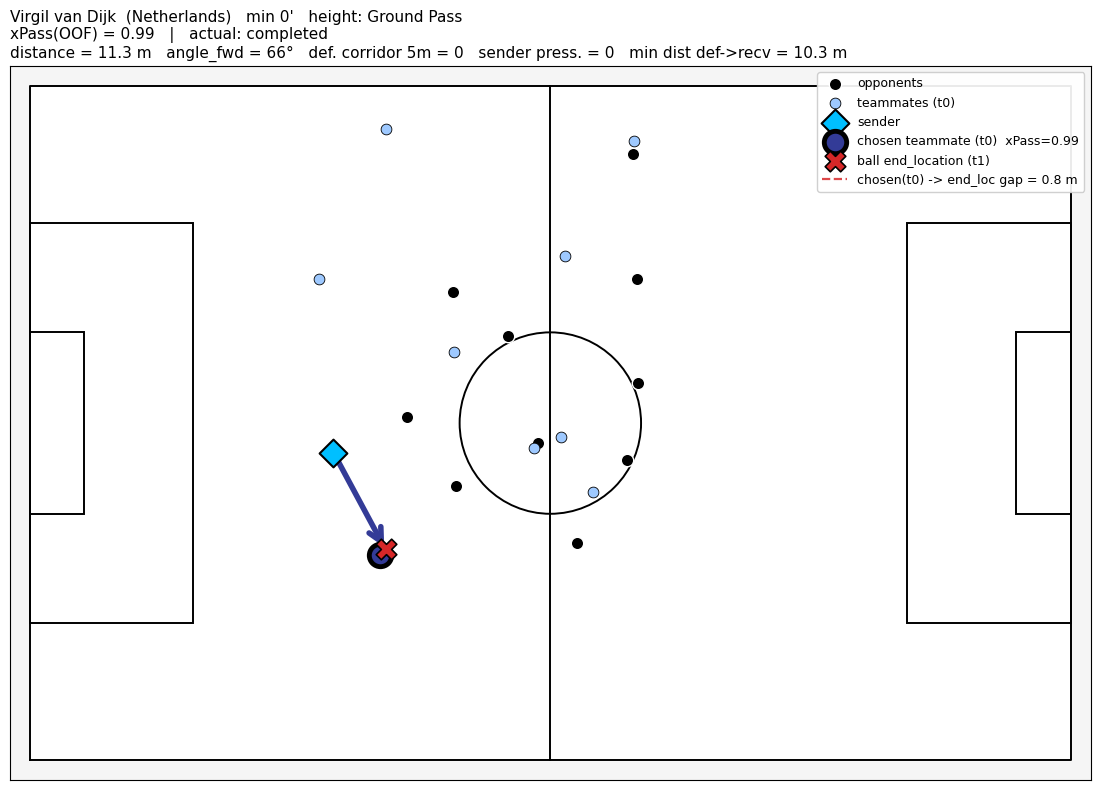

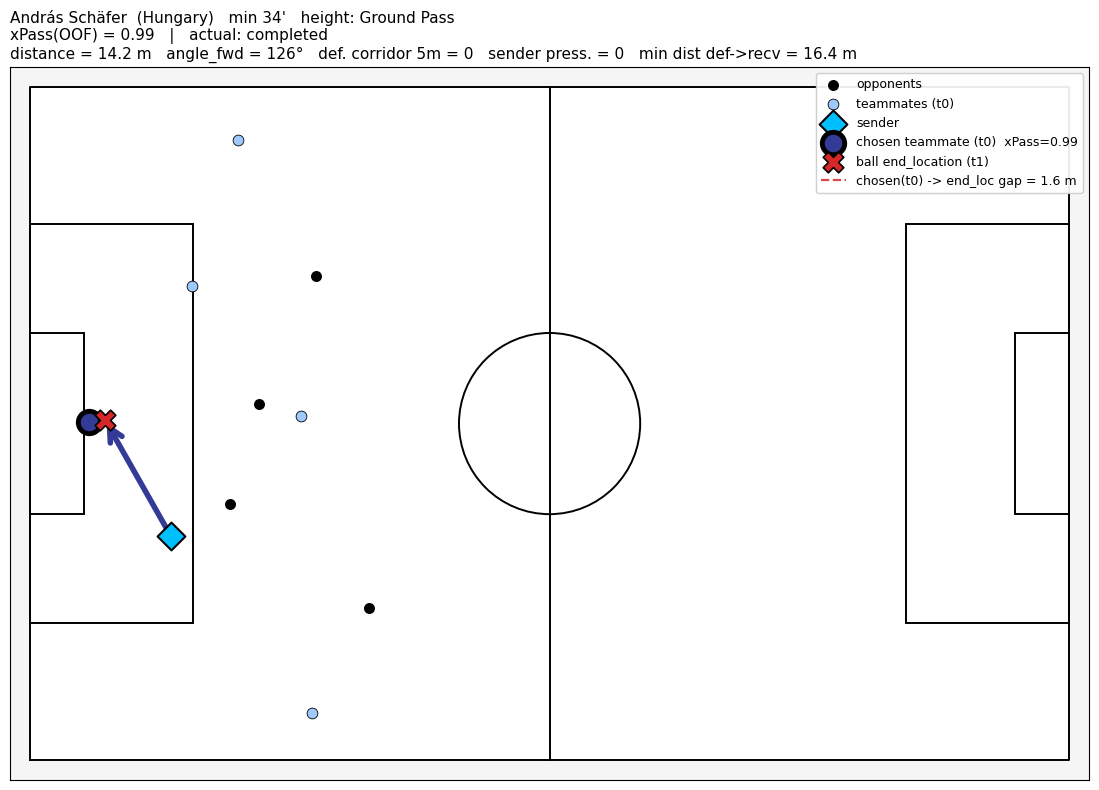

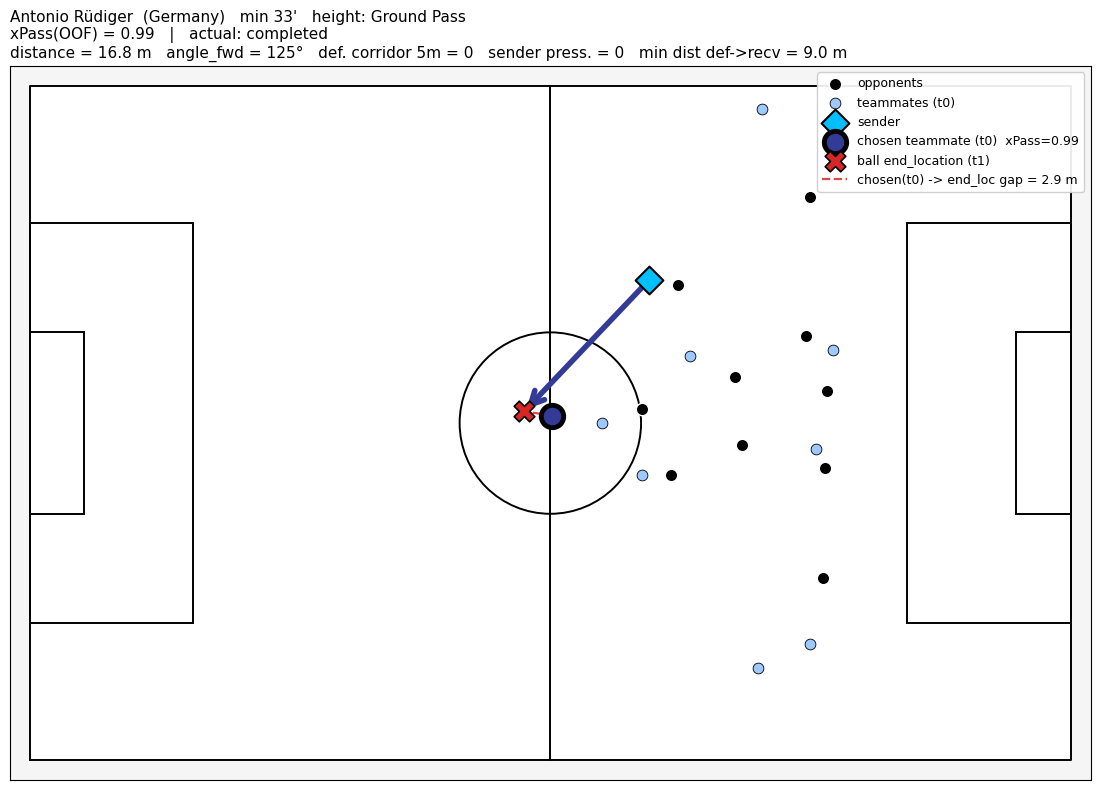

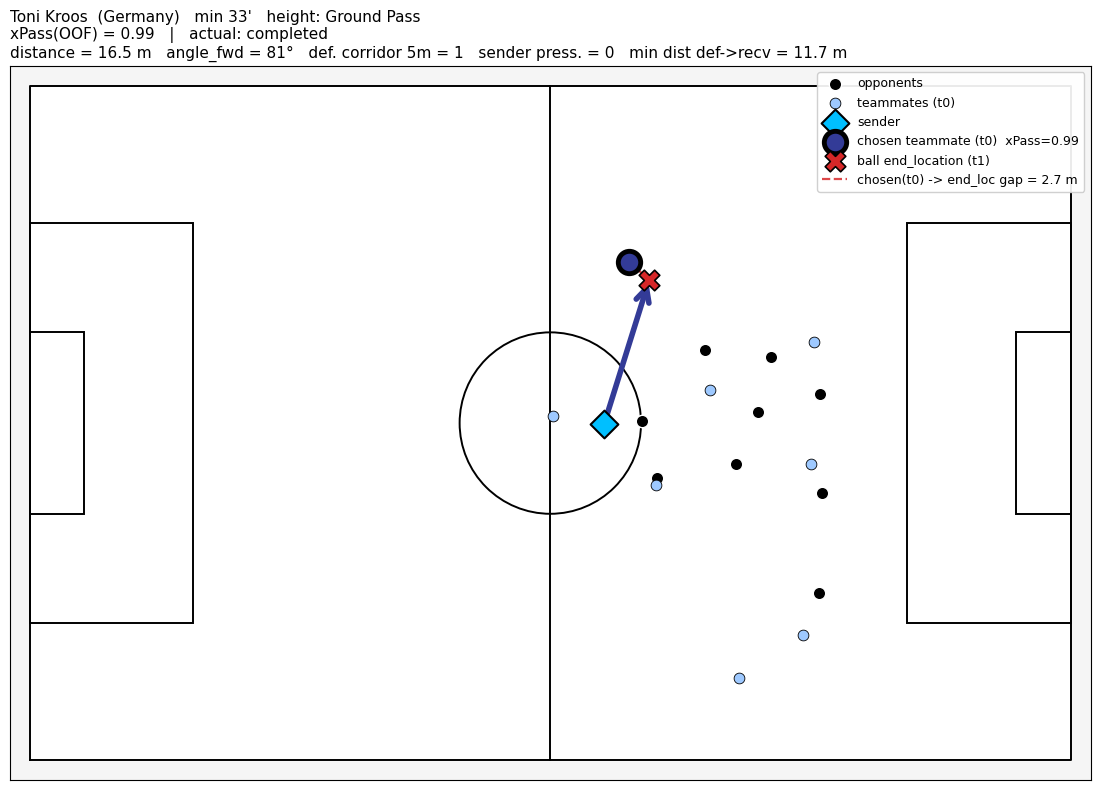

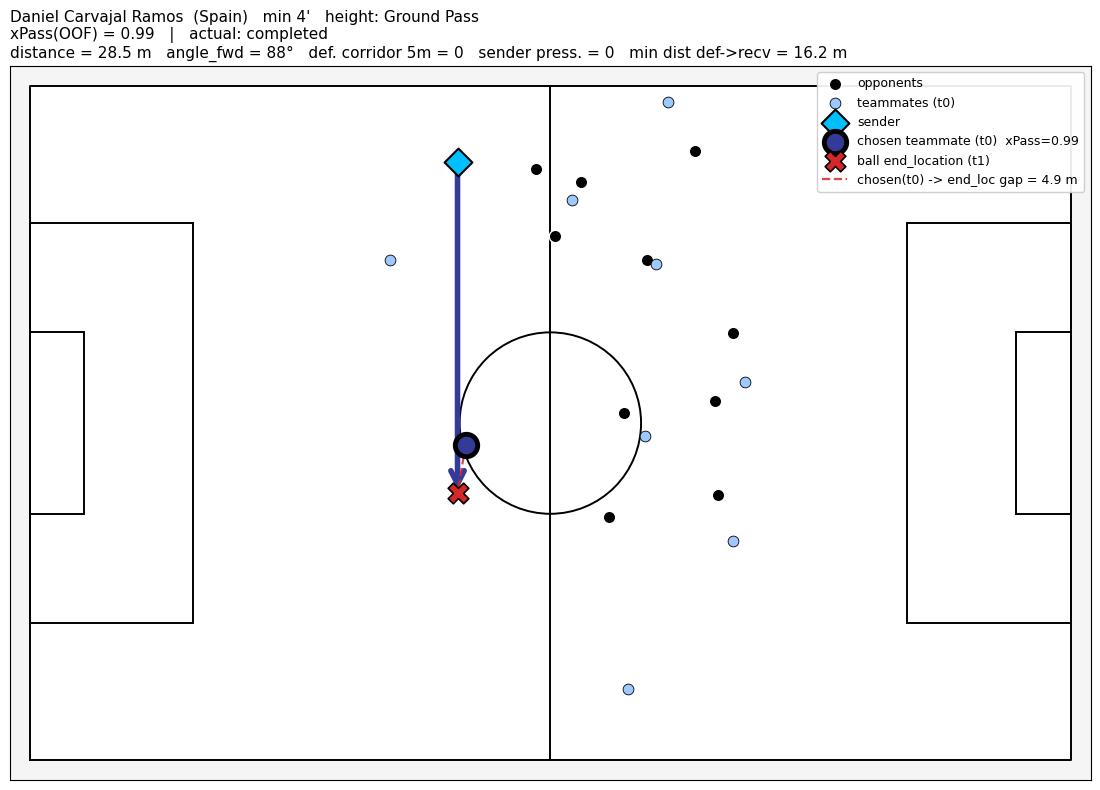

In [23]:
for ev_id in ex['event_id']:
    fig = viz.plot_pass_example(ev_id, merged)
    plt.show()

### 7.2 Low-xPass passes that completed

These are the passes the model called *hard* but the player completed anyway, the visual test is whether the situation actually looked hard. If many of them look easy, the feature set is missing something.

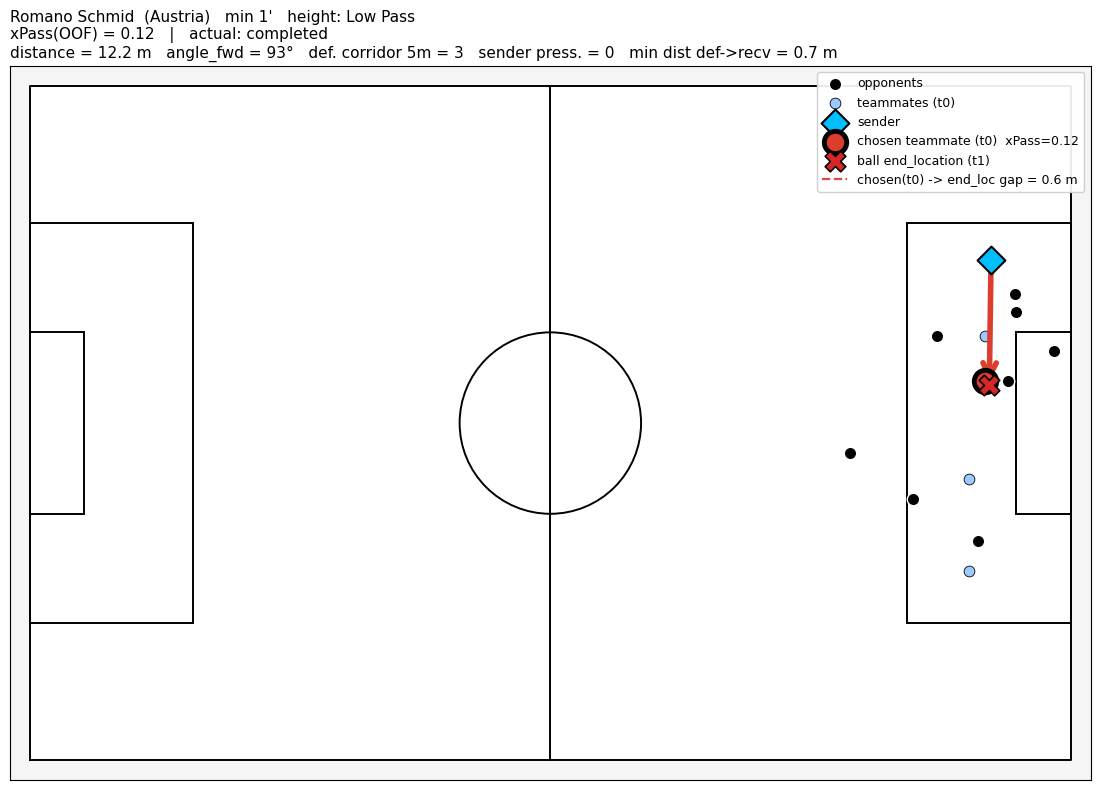

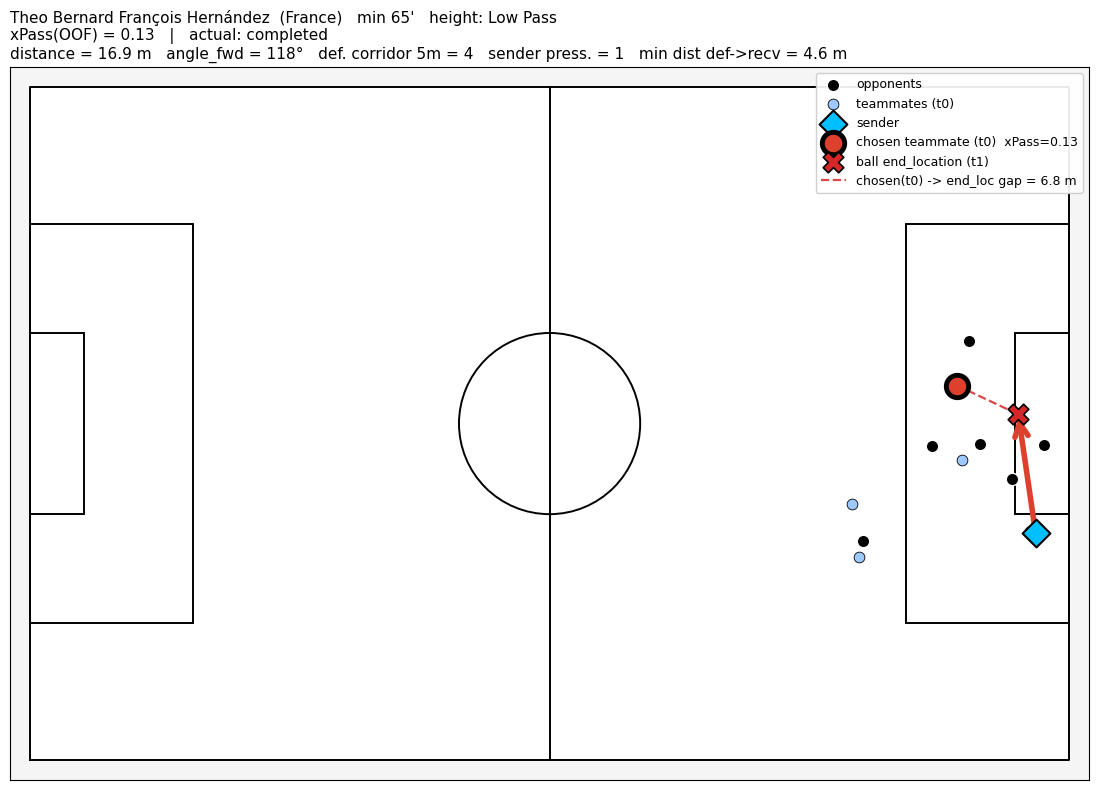

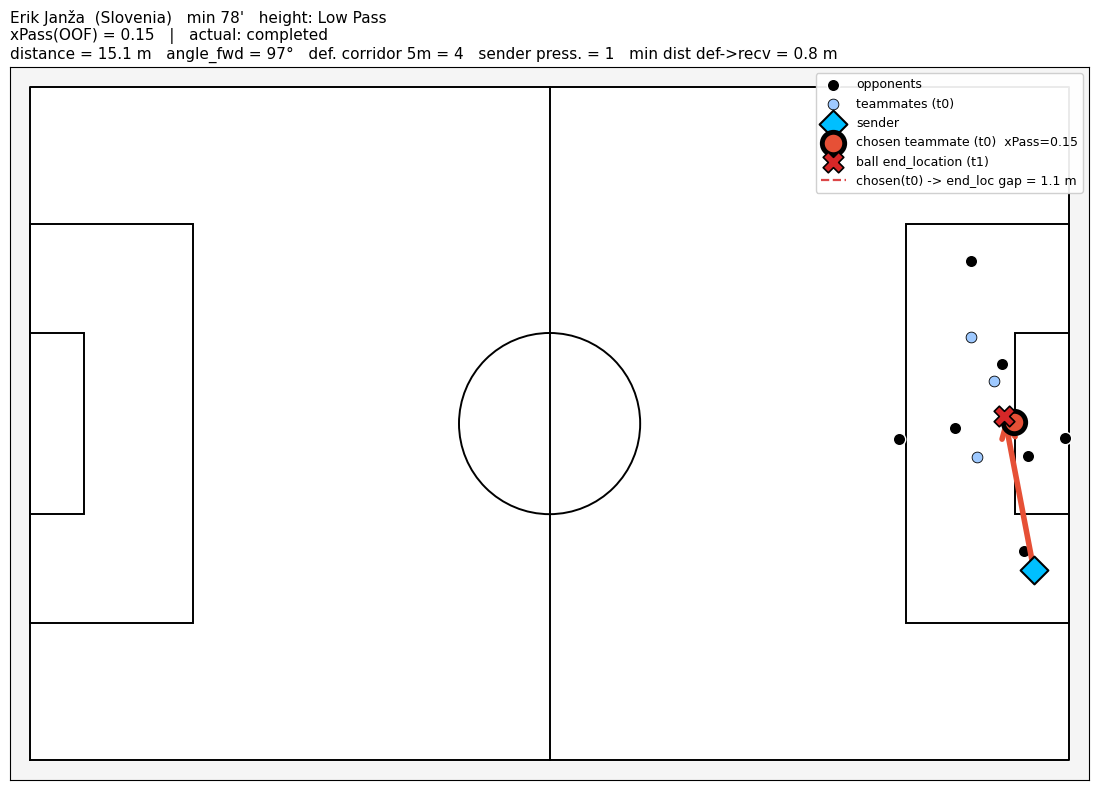

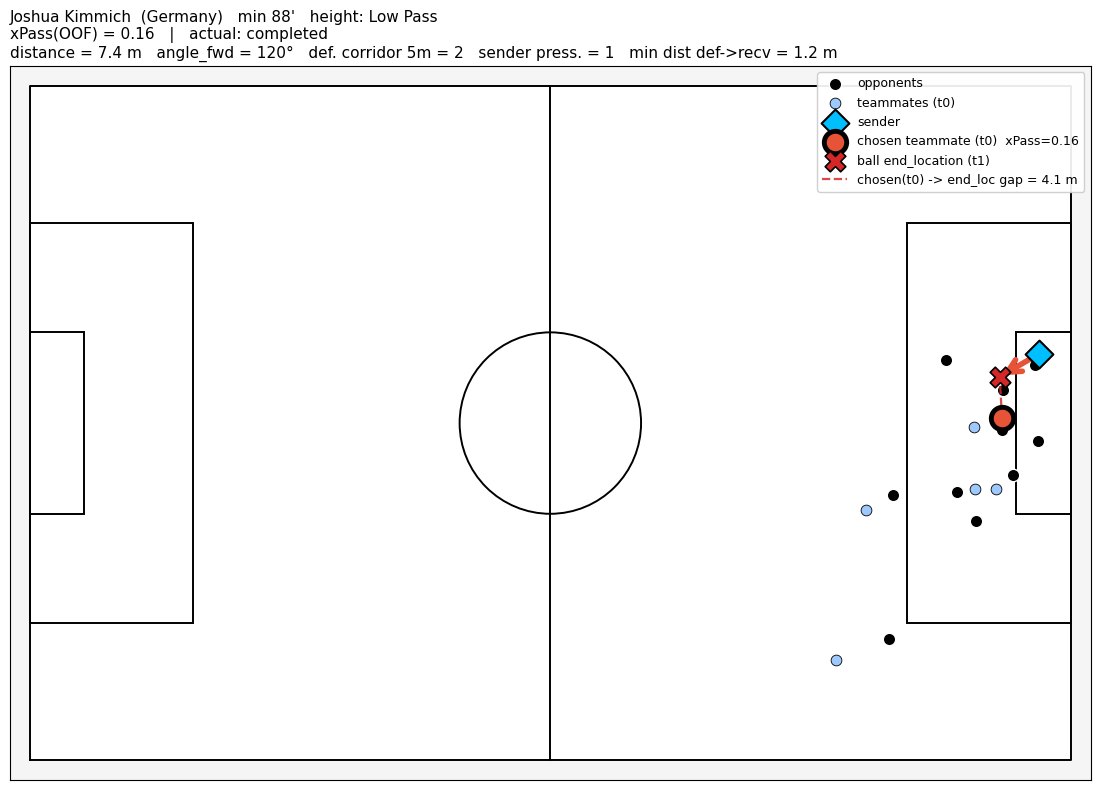

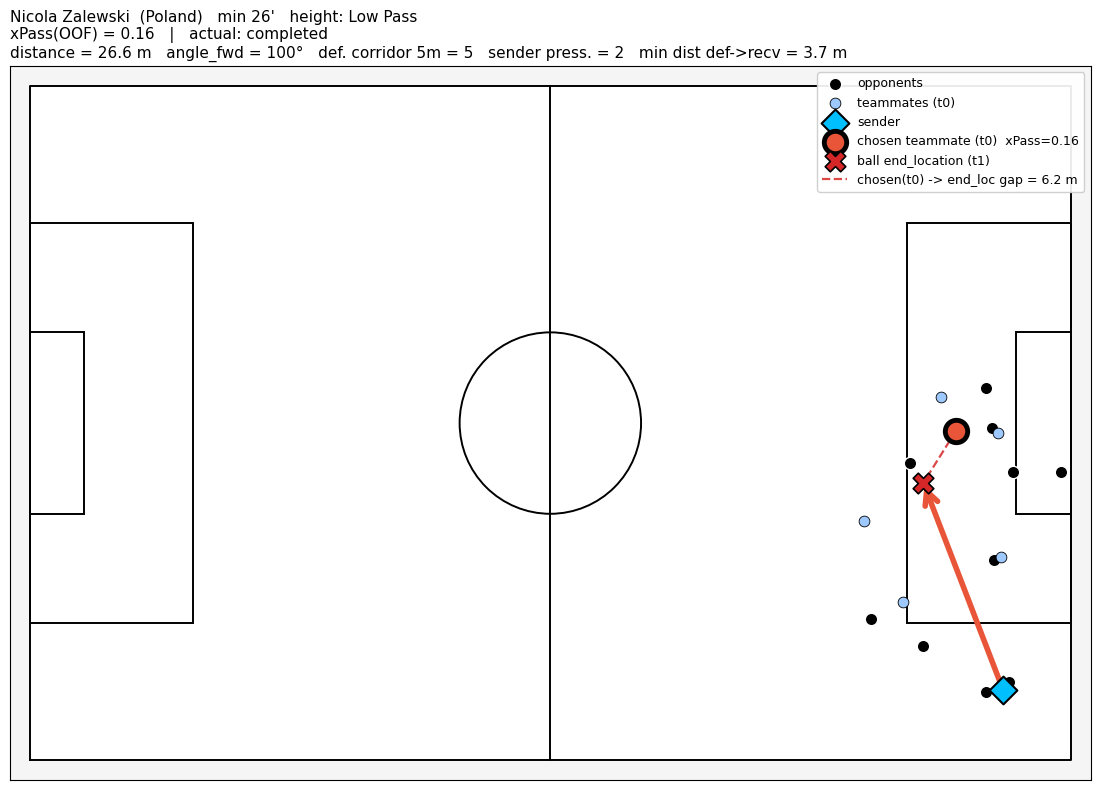

In [24]:
ex = viz.pick_examples(merged, kind='low_xpass_made', k=5)
for ev_id in ex['event_id']:
    fig = viz.plot_pass_example(ev_id, merged)
    plt.show()

### 7.3 High-xPass passes that did NOT complete

The reverse: passes the model thought were easy that didn't get through. Often these are execution errors, but if a pattern emerges (e.g. always a specific zone) the feature set may miss it.

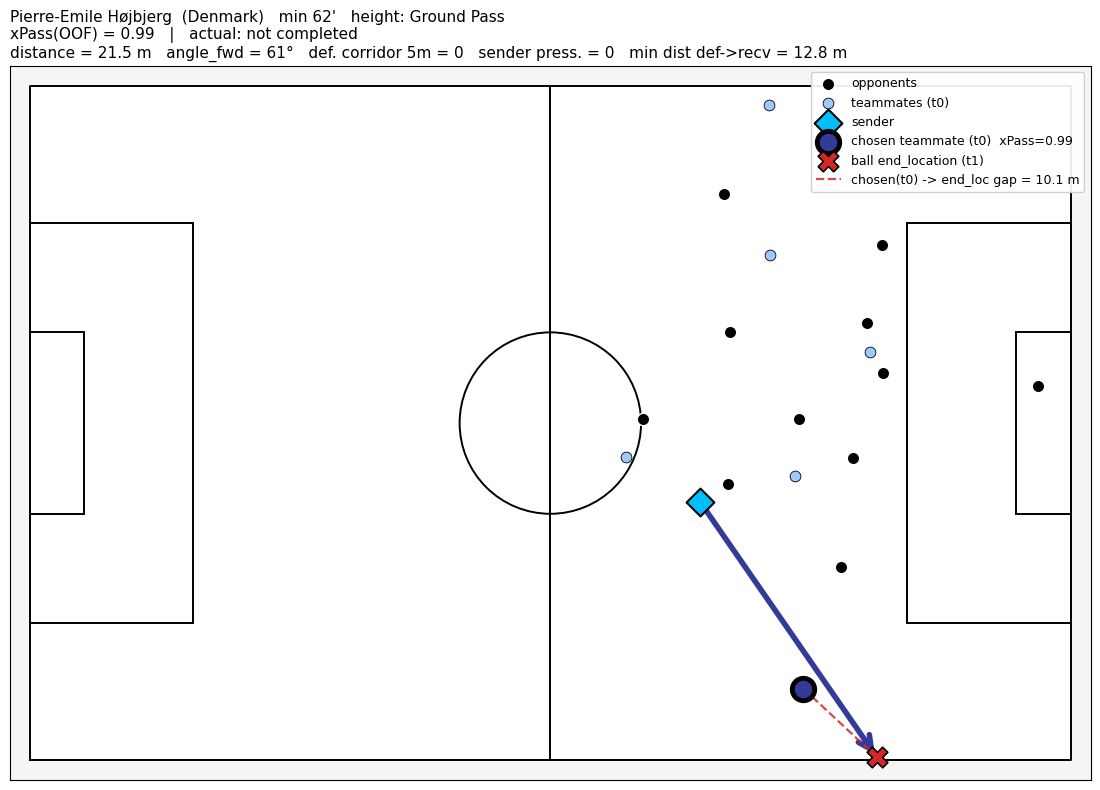

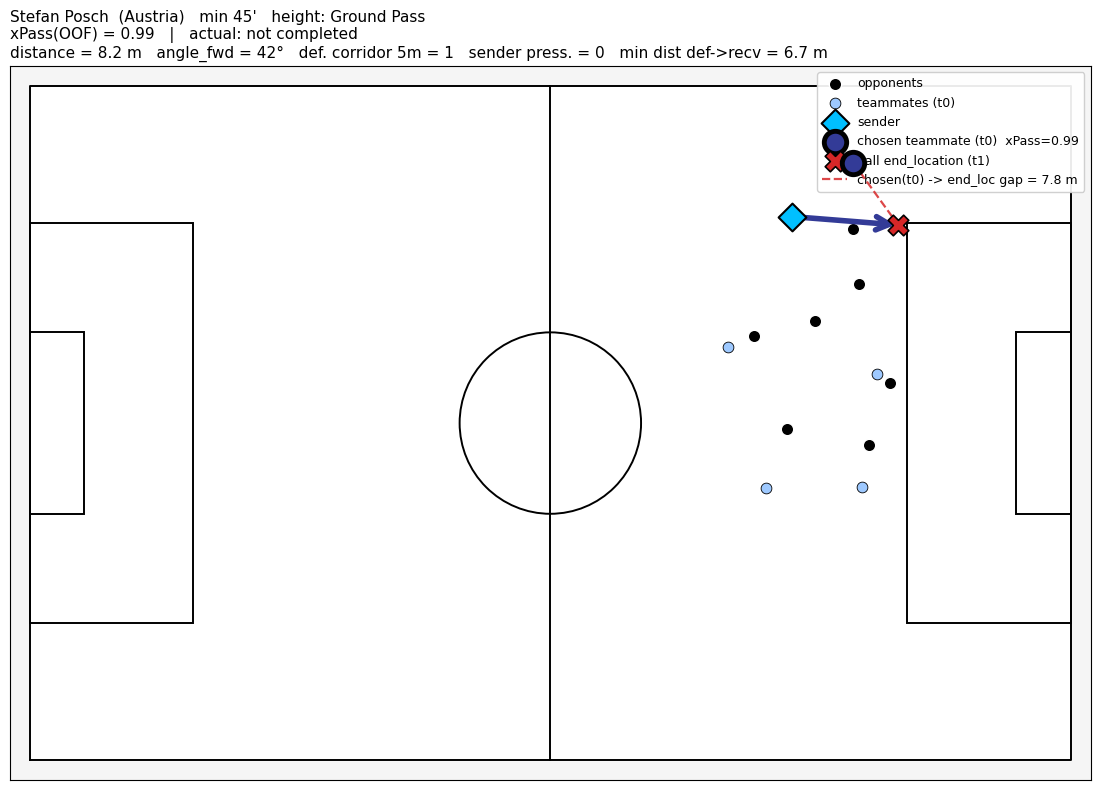

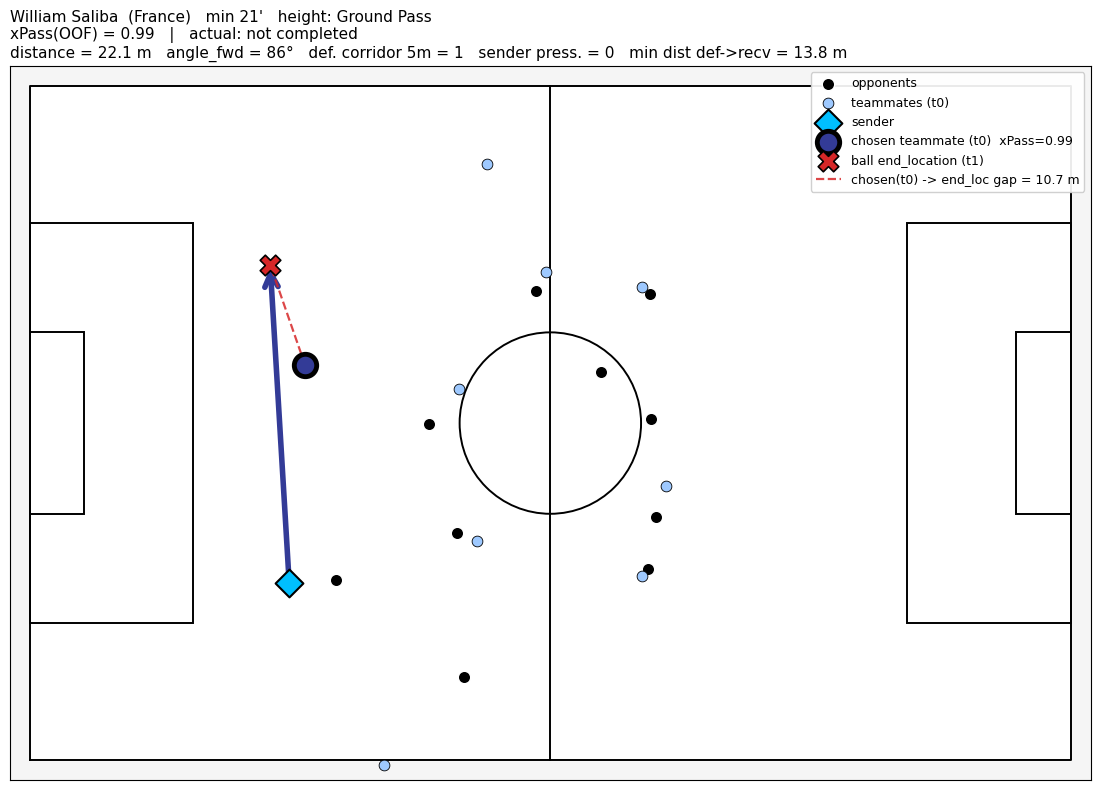

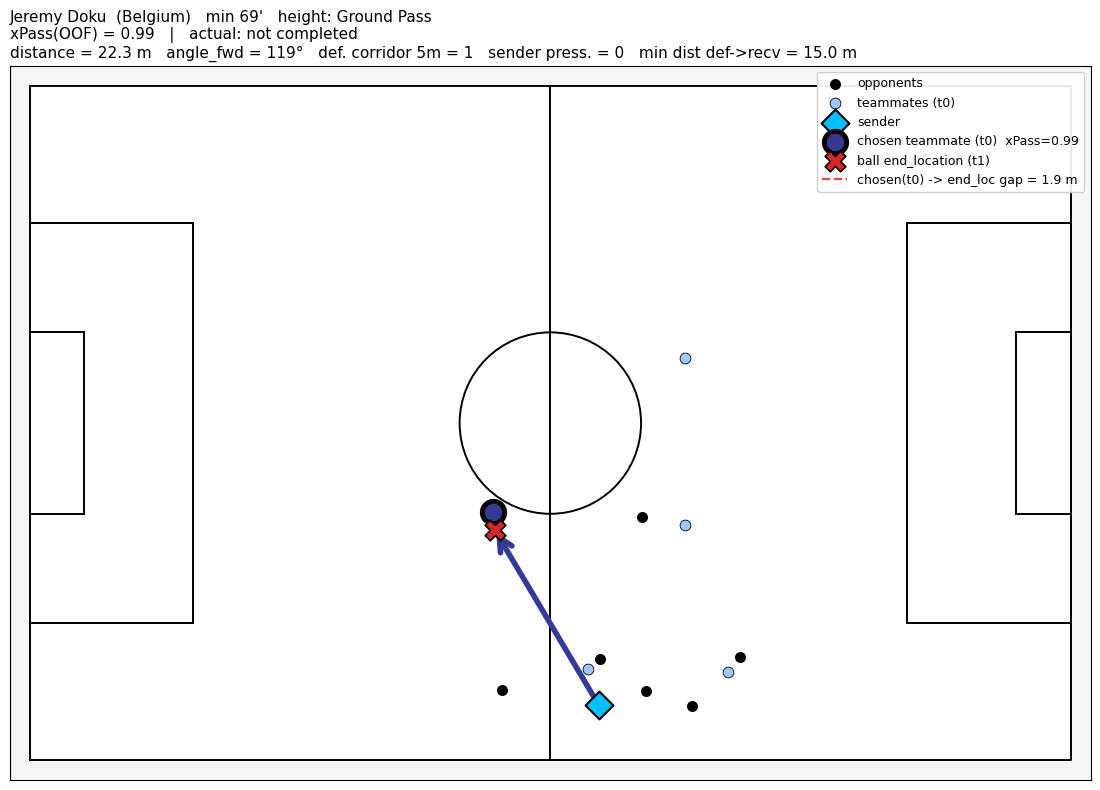

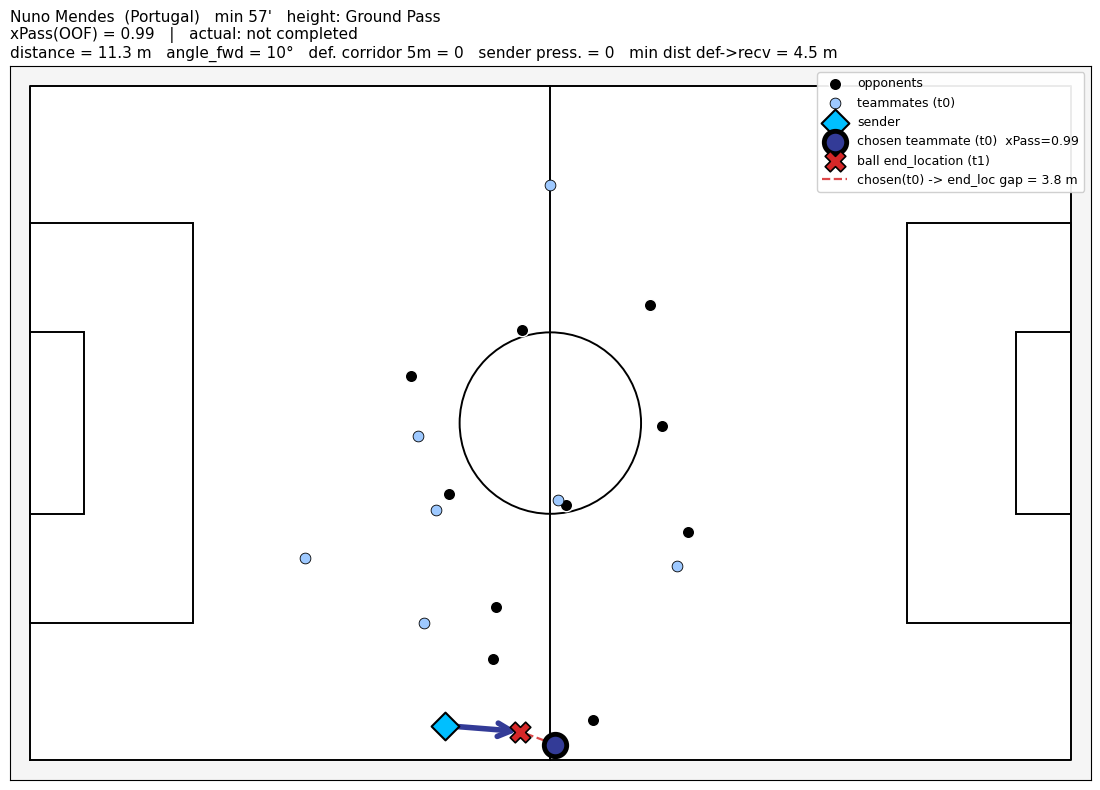

In [25]:
ex = viz.pick_examples(merged, kind='high_xpass_missed', k=5)
for ev_id in ex['event_id']:
    fig = viz.plot_pass_example(ev_id, merged)
    plt.show()

### 7.4 High-pressure passes (sender ≥ 2 opponents @ 2.5 m)

This is the segment where the downstream decision-quality metric will be most sensitive. The xPass values should be lower on average.

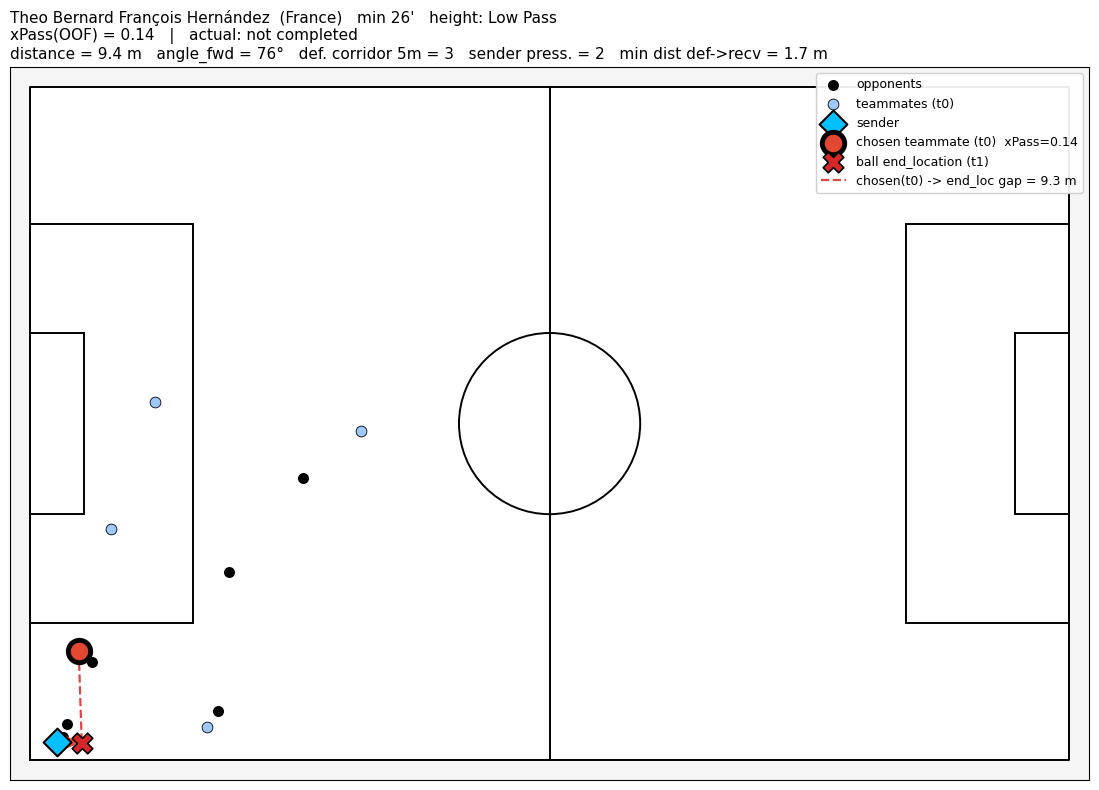

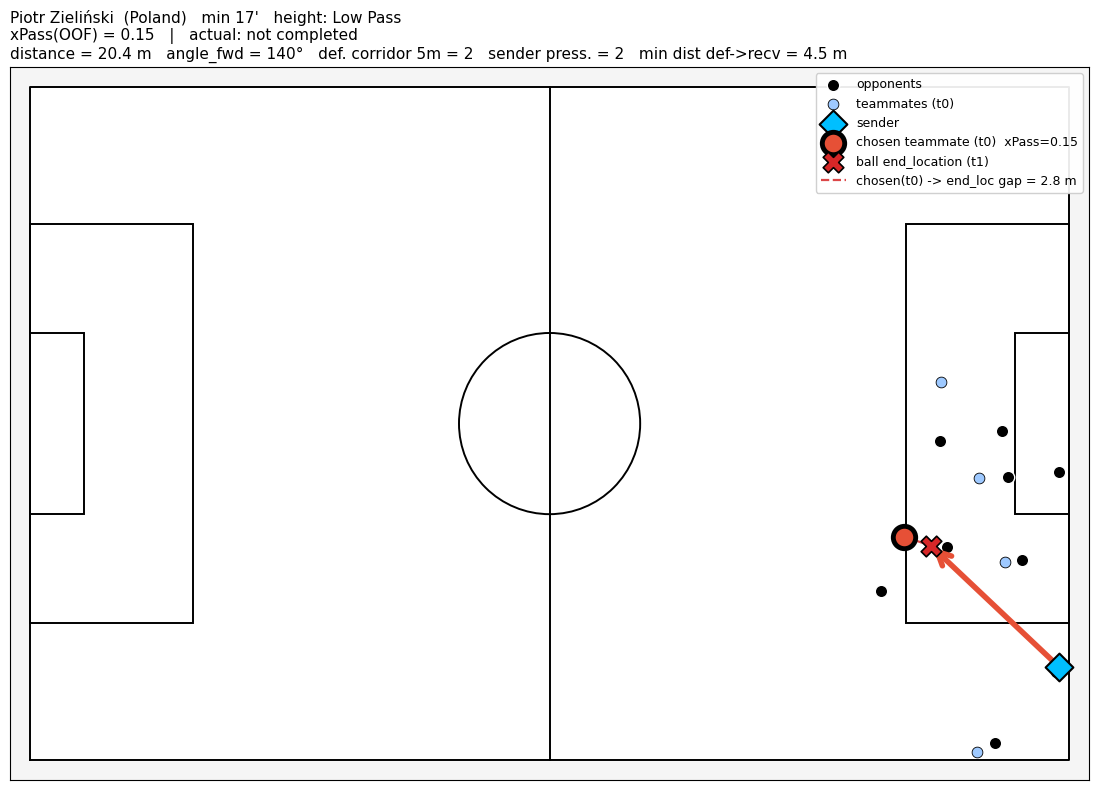

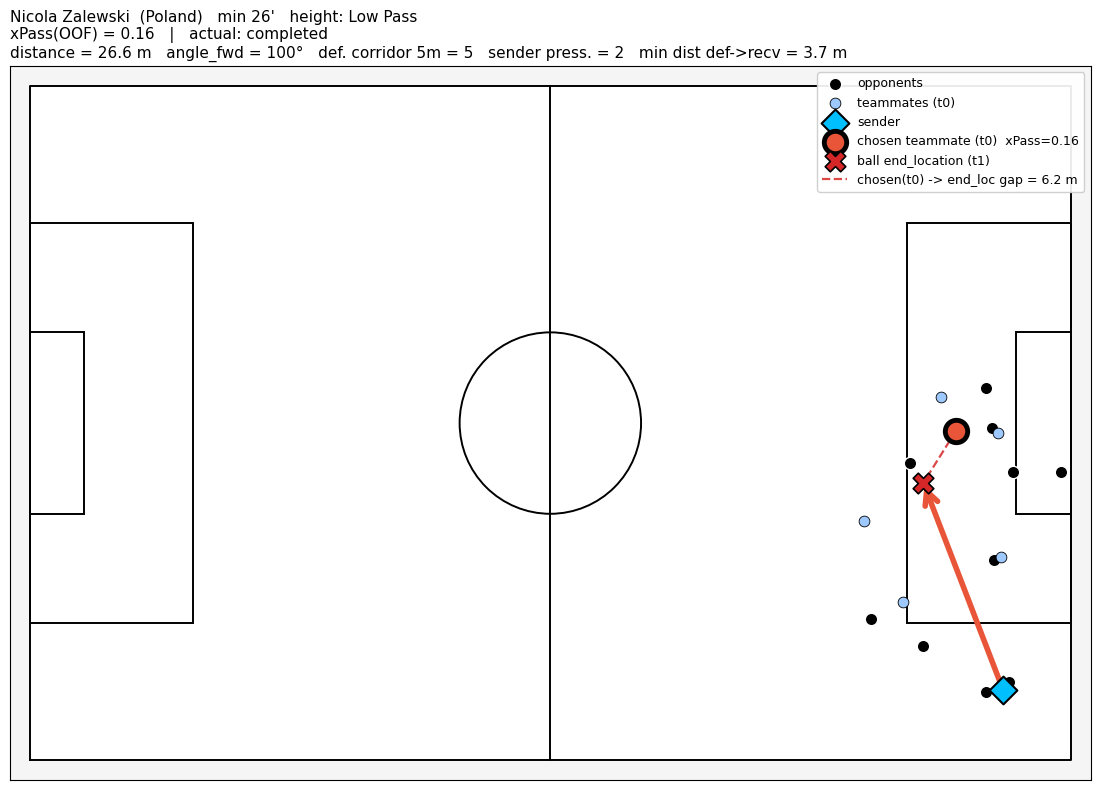

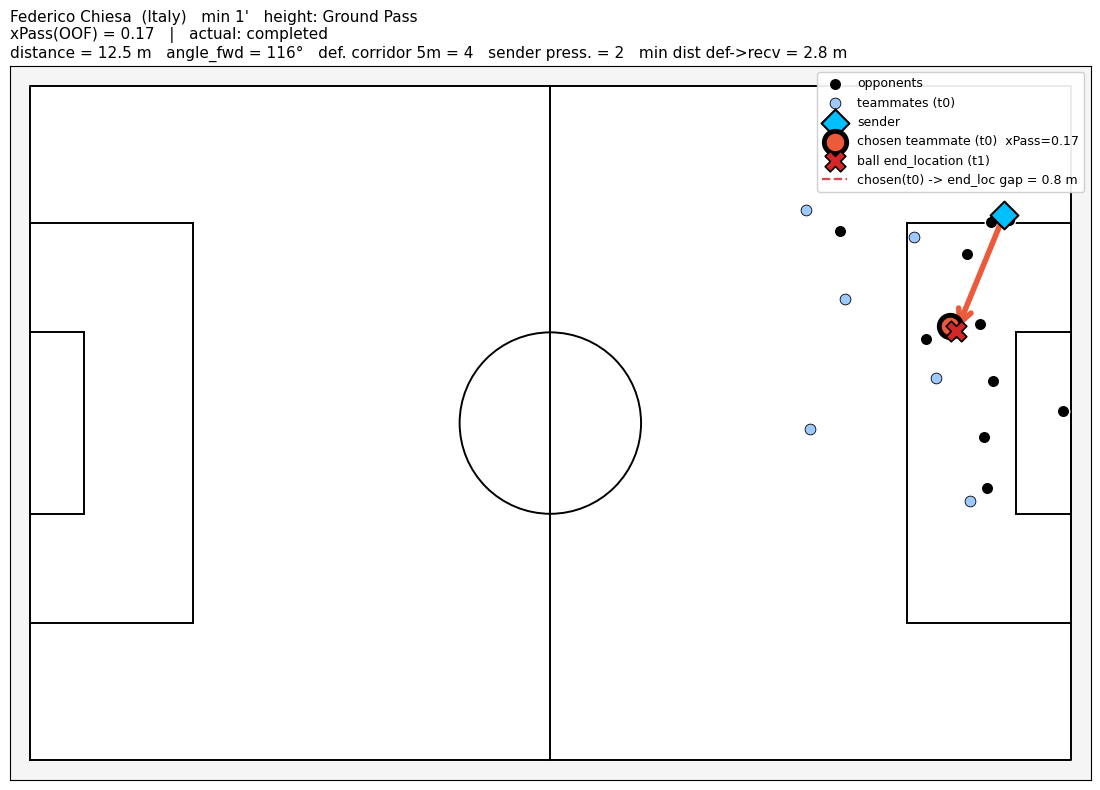

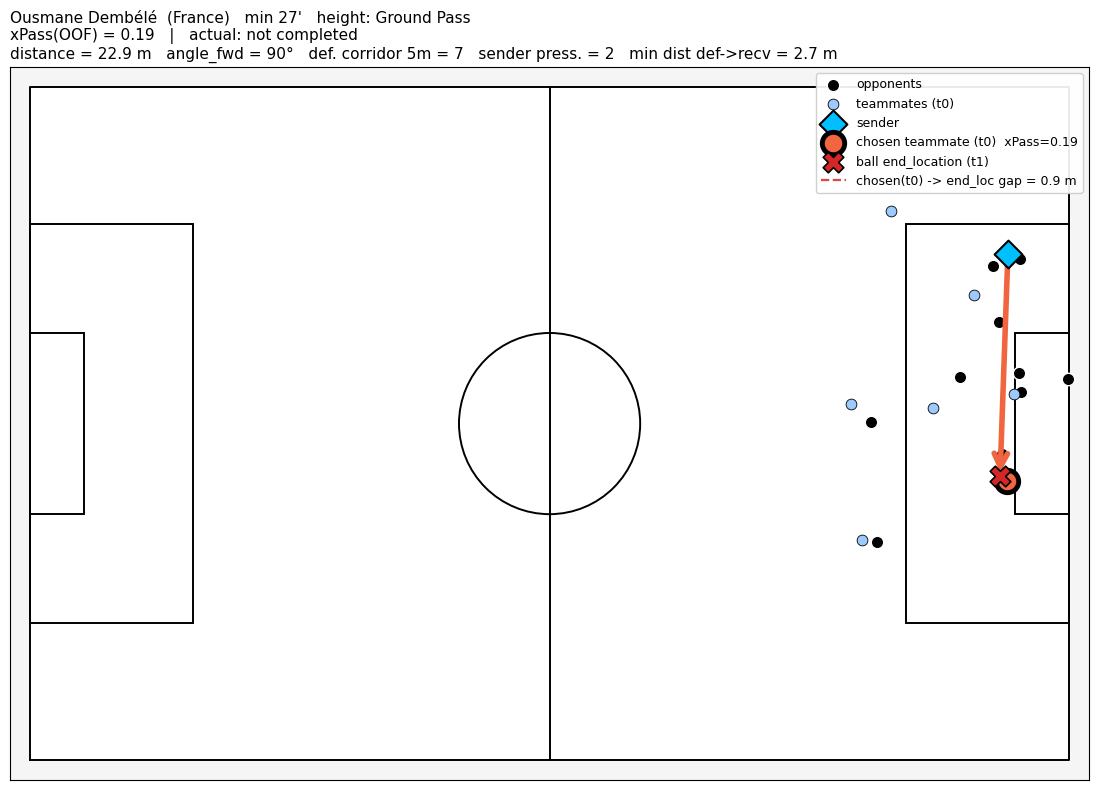

In [26]:
ex = viz.pick_examples(merged, kind='high_pressure', k=5)
for ev_id in ex['event_id']:
    fig = viz.plot_pass_example(ev_id, merged)
    plt.show()

### 7.5 Compact panel (6 events at once)

For audit / proposal figures.

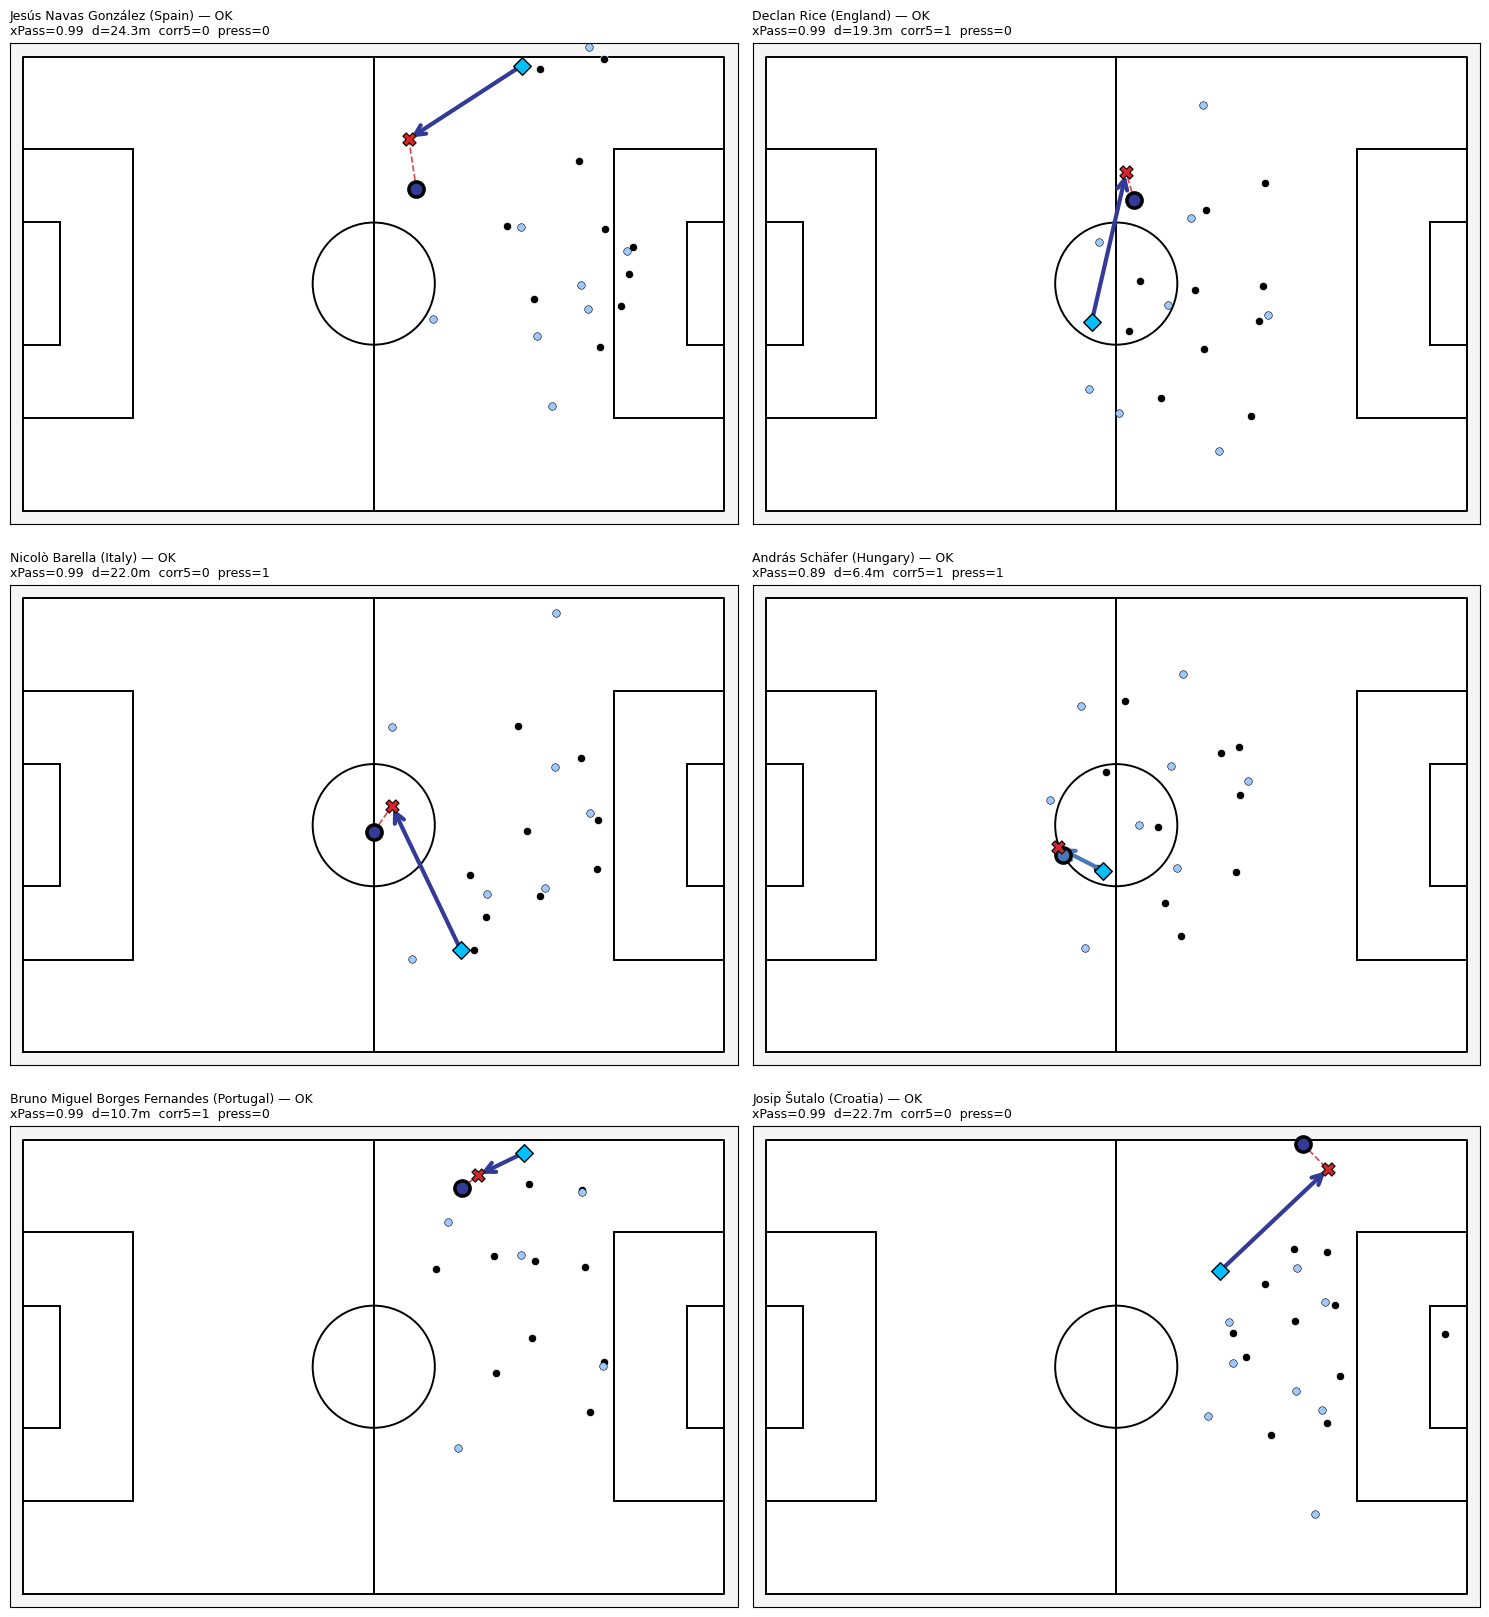

In [27]:
ex = viz.pick_examples(merged, kind='random', k=6)
viz.plot_pass_grid(ex['event_id'].tolist(), merged, ncols=2);

## Section 8 — Pass alternatives (xPass per candidate)

So far we trained and evaluated xPass on the *chosen* pass of each event.
The DQ index will need something different: for every event, the xPass of
**every visible teammate** as a candidate target, so we can compare the
choice the player made against the available options.

This section expands the corpus from one row per event into one row per
(event, candidate teammate) pair, scores every row with the calibrated
GBM, and explores the resulting decision space:

* shape of the table (how many candidates per event on average)
* `regret = best_alternative_xpass − chosen_xpass` distribution
* visualisation of a few events with all candidates colour-coded by xPass

The pass-height assumption for ALL candidates (chosen and alternatives)
is `Ground Pass` — neutral, what the player would default to if we had
to guess. 

### 8.1 Build the alternatives table (cached)

In [28]:
from pathlib import Path

if cfg.ALTERNATIVES_PATH.exists():
    print(f'loading cached: {cfg.ALTERNATIVES_PATH}')
    alts = pd.read_parquet(cfg.ALTERNATIVES_PATH)
else:
    print('expanding corpus into alternatives (~2 min)...')
    alts = features.features_for_all_candidates(dq_corpus_fr)
    alts['xpass'] = xpass_model.predict_proba(alts)
    alts.to_parquet(cfg.ALTERNATIVES_PATH, index=False)
    print(f'saved: {cfg.ALTERNATIVES_PATH}  ({len(alts):,} rows)')

alts.shape, alts['xpass'].describe().round(3)

loading cached: /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Decision_Quality/data/alternatives.parquet


((231162, 21),
 count    231162.000
 mean          0.852
 std           0.164
 min           0.117
 25%           0.773
 50%           0.916
 75%           0.987
 max           0.990
 Name: xpass, dtype: float64)

### 8.2 How many candidates per event

count    32181.0
mean         7.2
std          1.5
min          1.0
5%           4.0
25%          6.0
50%          7.0
75%          8.0
95%          9.0
max         10.0
dtype: float64


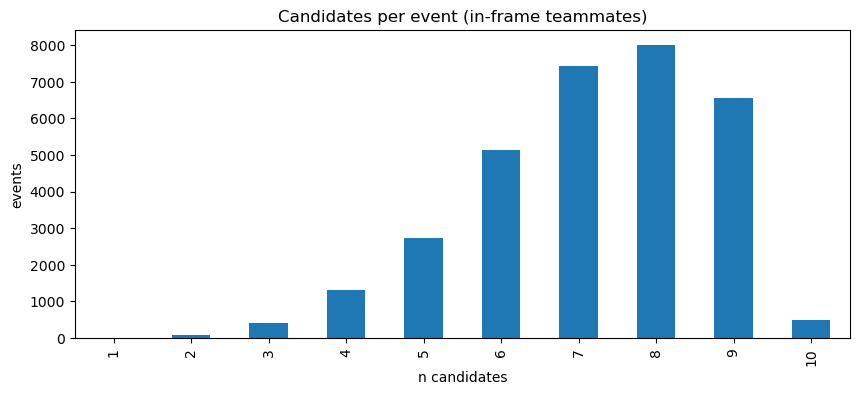

In [29]:
n_per_event = alts.groupby('event_id').size()
print(n_per_event.describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(1))
ax = n_per_event.value_counts().sort_index().plot(
    kind='bar', figsize=(10, 4),
    title='Candidates per event (in-frame teammates)',
    color='#1f77b4')
ax.set_xlabel('n candidates'); ax.set_ylabel('events');

### 8.3 Regret distribution

For each event:

* `chosen_xpass`  = xPass of the teammate the player actually chose
* `best_xpass`    = max xPass across all candidates (chosen included)
* `regret`        = `best_xpass − chosen_xpass`  (≥ 0; 0 means "you picked the safest")

A high-regret distribution would mean players often had safer
options than the one they took. In elite football this should be
small *on average* (players know what they are doing); a long right
tail is where the DQ index will eventually flag mis-decisions.


In [30]:
# chosen_xpass : xPass score the actual chosen target received
# best_xpass   : max xPass across all candidates (chosen included)
# regret       : best_xpass - chosen_xpass  (>= 0; 0 = picked the best)
chosen = (alts.loc[alts['is_chosen'], ['event_id', 'xpass']]
          .rename(columns={'xpass': 'chosen_xpass'})
          .set_index('event_id'))
best   = alts.groupby('event_id')['xpass'].max().rename('best_xpass')
n_cand = alts.groupby('event_id').size().rename('n_candidates')
per_event = pd.concat([chosen, best, n_cand], axis=1)
per_event['regret'] = per_event['best_xpass'] - per_event['chosen_xpass']

per_event[['chosen_xpass', 'best_xpass', 'regret']].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(3)


,chosen_xpass,best_xpass,regret
count,32181.000,32181.000,32181.000
mean,0.917,0.978,0.061
std,0.145,0.050,0.127
min,0.138,0.261,0.000
5%,0.568,0.930,0.000
25%,0.923,0.989,0.000
50%,0.989,0.990,0.000
75%,0.990,0.990,0.051
95%,0.990,0.990,0.366
max,0.990,0.990,0.833


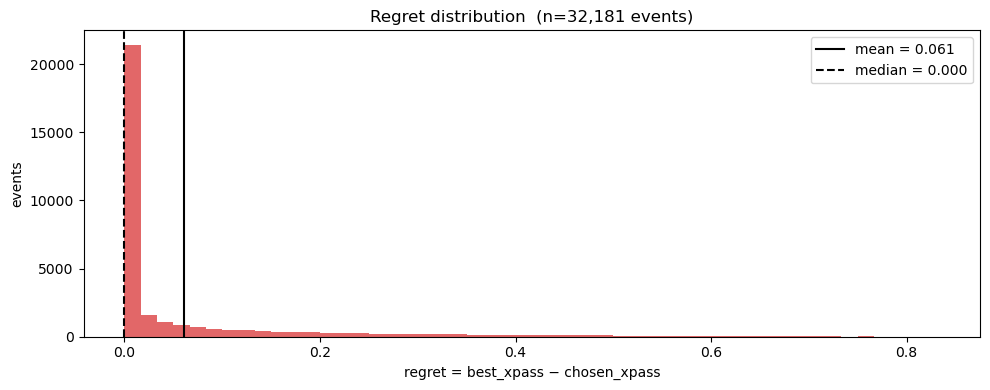

In [31]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(per_event['regret'], bins=50, color='#d62728', alpha=0.7)
ax.set_xlabel('regret = best_xpass − chosen_xpass')
ax.set_ylabel('events')
ax.set_title(f"Regret distribution  (n={len(per_event):,} events)")
ax.axvline(per_event['regret'].mean(), color='black', lw=1.5,
           label=f"mean = {per_event['regret'].mean():.3f}")
ax.axvline(per_event['regret'].median(), color='black', lw=1.5,
           linestyle='--', label=f"median = {per_event['regret'].median():.3f}")
ax.legend(); plt.tight_layout(); plt.show();

### 8.4 Visualisations — decision space for a few events

Pitch view: every visible teammate as a coloured dot (red→yellow→blue =
xPass low→high), the chosen receiver highlighted with a thick border, an
arrow from sender to chosen. The legend on the right shows opponents in
black.

Two examples per regret regime:

* **Low regret** — the player picked the option the model also rates best.
* **High regret** — the player chose a noticeably riskier option than the
  available alternatives.


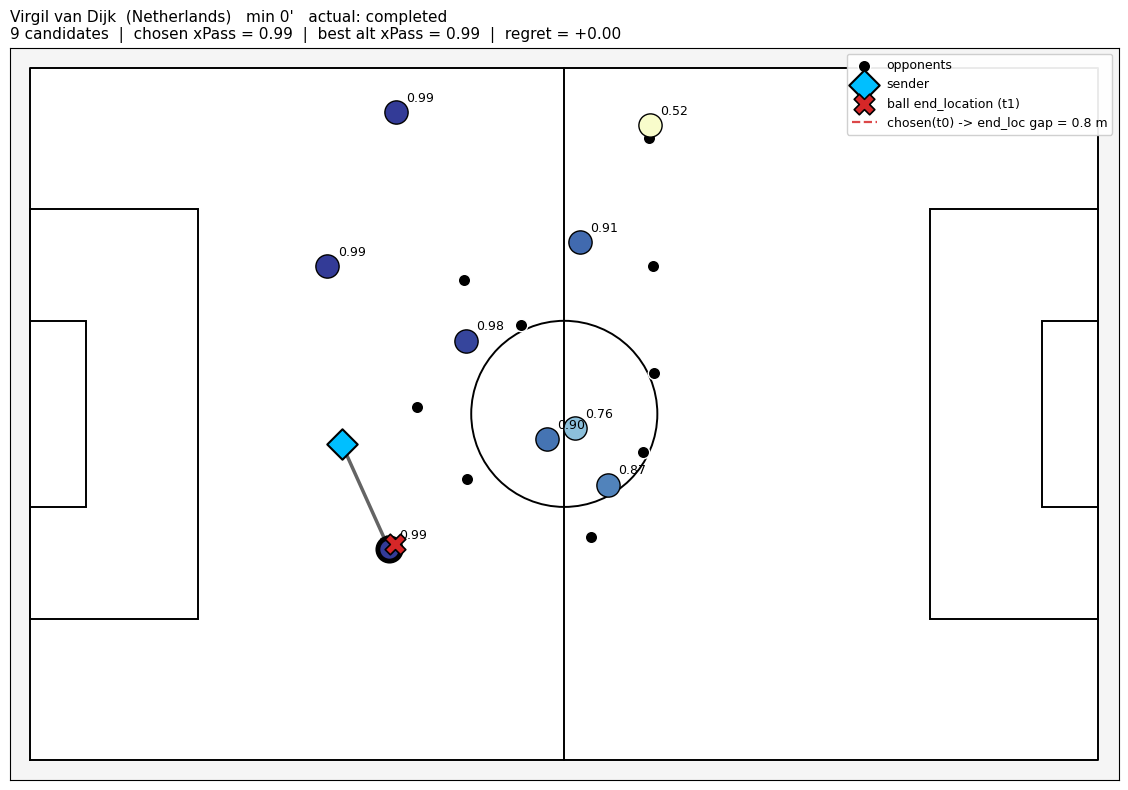

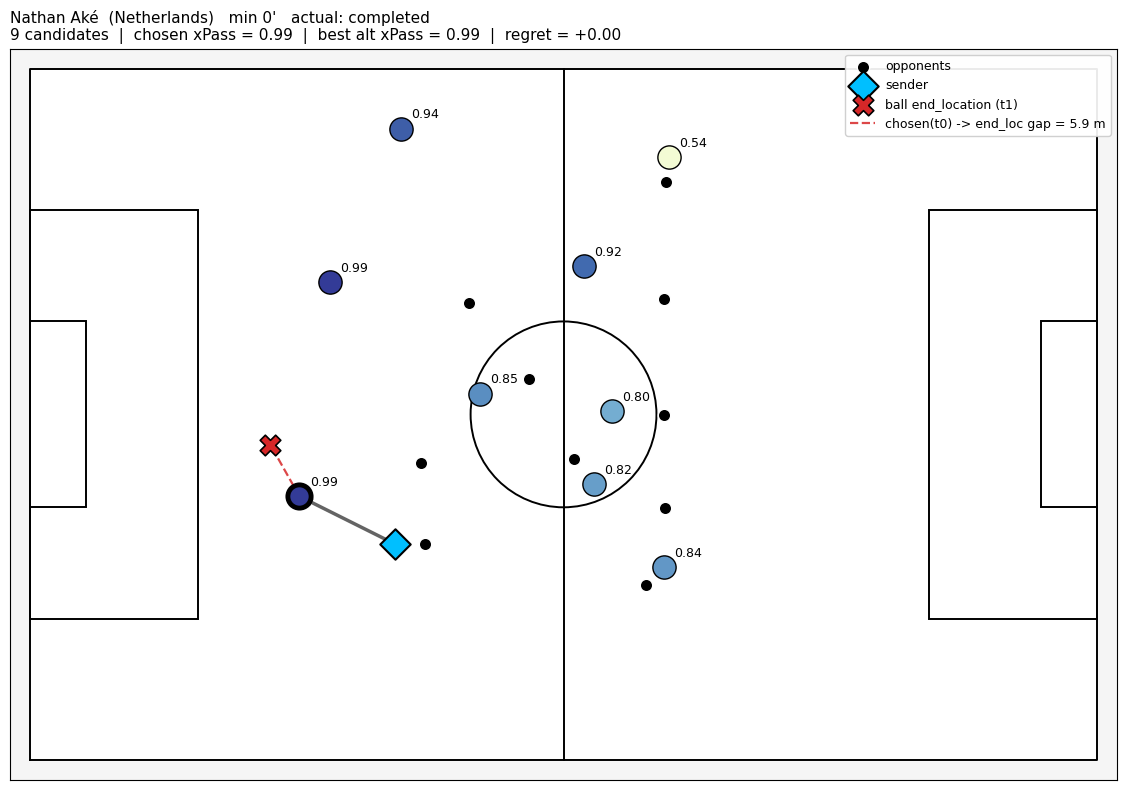

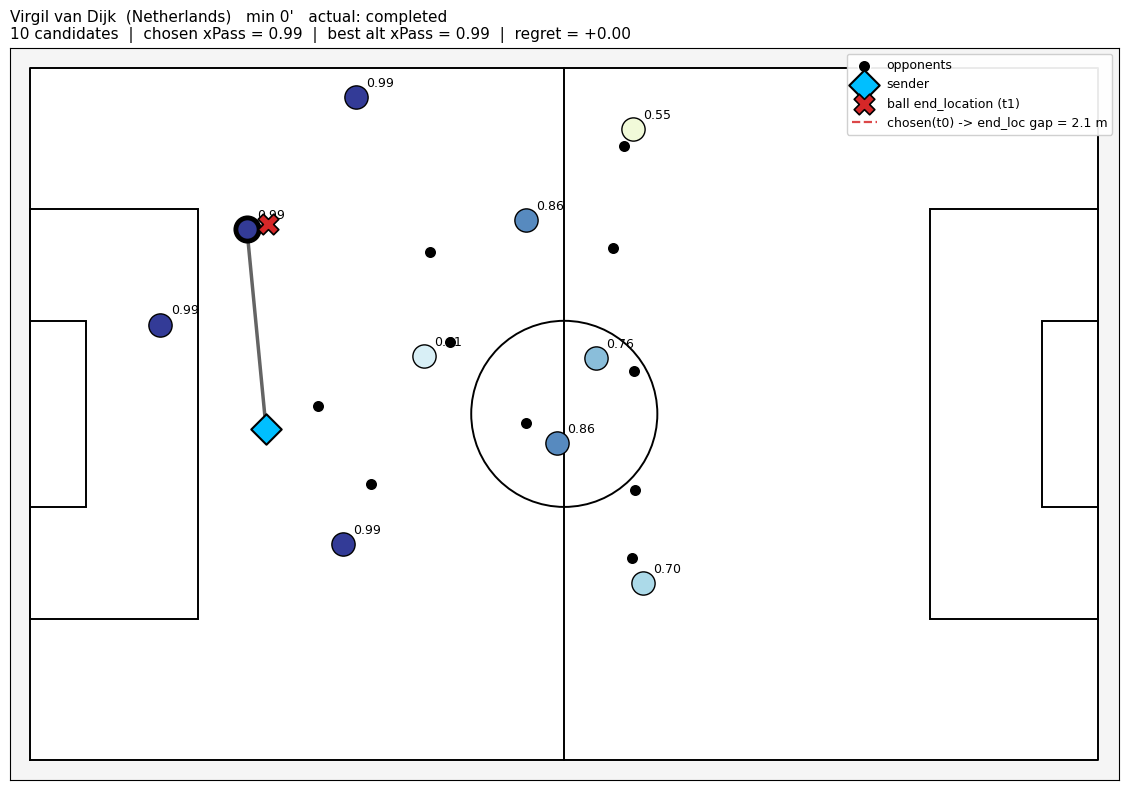

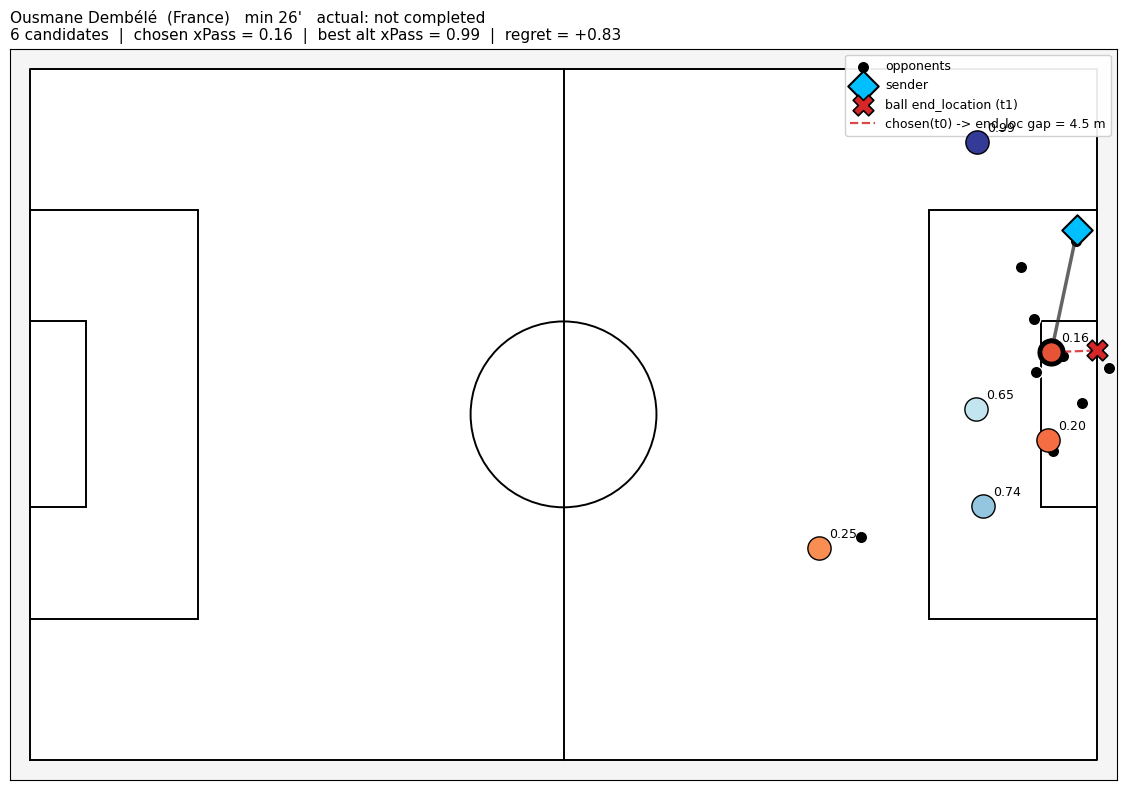

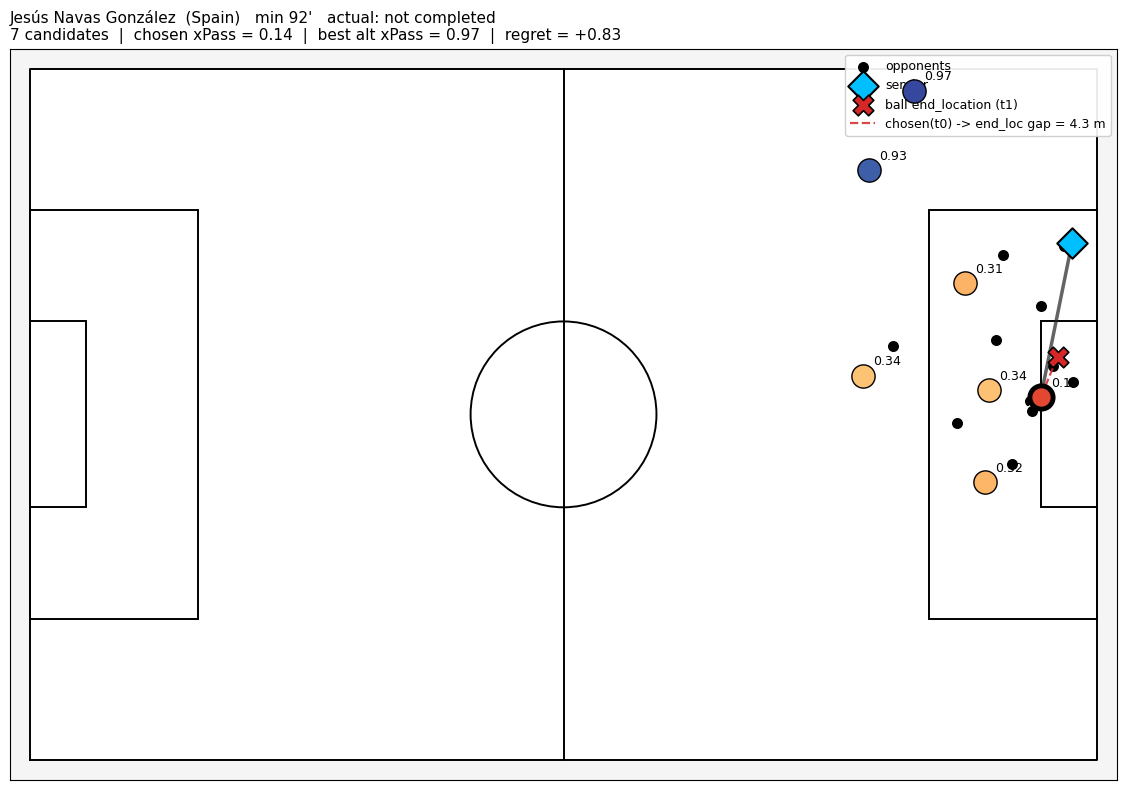

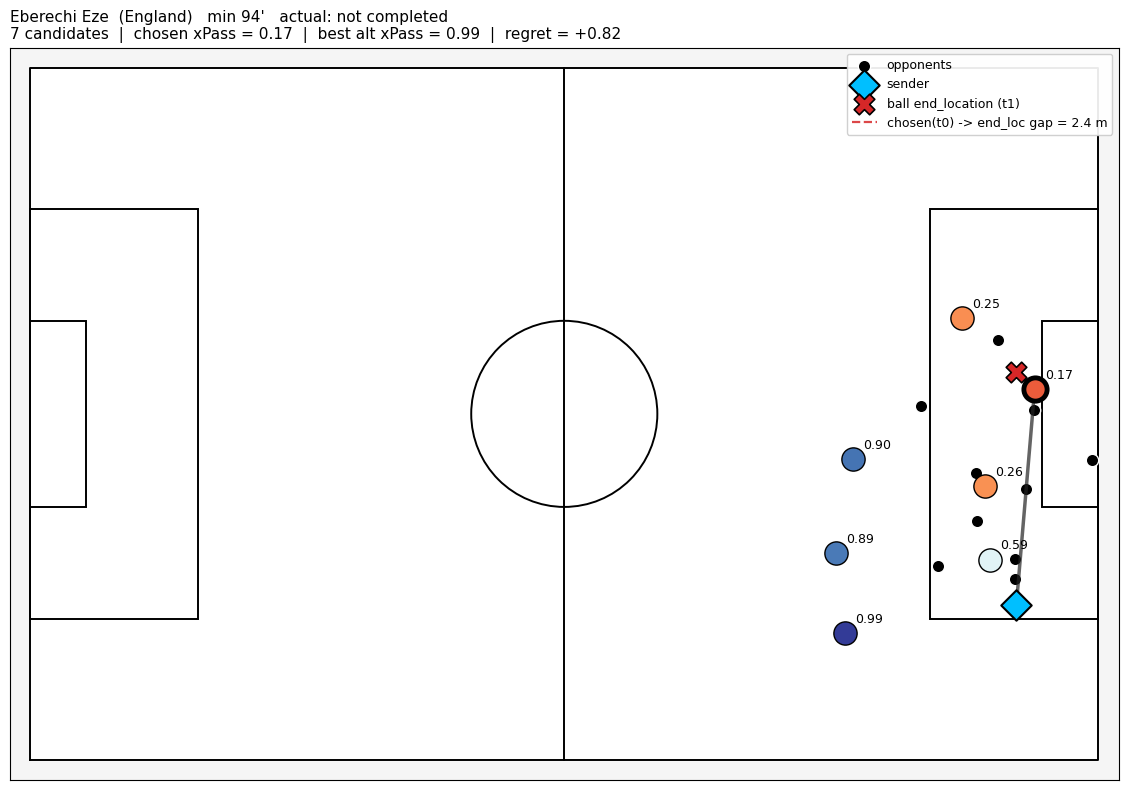

In [32]:
low_regret  = per_event.nsmallest(3, 'regret').index.tolist()
high_regret = per_event.nlargest(3, 'regret').index.tolist()
for ev_id in low_regret + high_regret:
    fig = viz.plot_pass_alternatives(ev_id, alts, dq_corpus_fr)
    plt.show()

### 8.5 Aggregate insight — chosen vs best alternative

How often does the chosen pass equal the best-by-xPass option? When it
does not, how big is the gap? These two numbers are the empirical
foundation for the future DQ index — once we add EPV, the same
framework will rank decisions by *expected value* instead of by xPass
alone.


In [33]:
share_chose_best = (per_event['regret'] < 0.001).mean()
print(f'share where chosen == best xPass : {share_chose_best:.1%}')
print(f'mean regret (all events)         : {per_event["regret"].mean():.3f}')
print(f'mean regret (when not best)      : '
      f'{per_event.loc[per_event["regret"] >= 0.001, "regret"].mean():.3f}')
print()
print('Regret split by actual outcome:')
outcome_lookup = (dq_corpus_fr[['event_id', 'pass_complete']]
                  .drop_duplicates('event_id')
                  .set_index('event_id'))
outcome_regret = per_event.join(outcome_lookup, how='inner')
print(outcome_regret.groupby('pass_complete')['regret']
      .describe(percentiles=[0.5, 0.95]).round(3))


share where chosen == best xPass : 56.6%
mean regret (all events)         : 0.061
mean regret (when not best)      : 0.140

Regret split by actual outcome:
                 count   mean    std  min    50%    95%    max
pass_complete                                                 
0               3112.0  0.327  0.187  0.0  0.323  0.640  0.833
1              29069.0  0.032  0.076  0.0  0.000  0.196  0.773


### 8.6 Visual proof — chosen vs best xPass, split by outcome

Two side-by-side panels read the same way: each event is one point, the diagonal `y = x` marks regret = 0 (the chosen pass was already the best available xPass). Splitting by outcome makes the §8.5 result visible:

* **Completed** (left): the green cloud should hug the diagonal in the upper-right corner — when players completed a pass, they had usually already picked the safest option.
* **Failed** (right): the red cloud should sit much further from the diagonal and span a much wider `chosen_xpass` range — failed passes were systematically riskier than the available alternatives.

Both panels share the same axes so the difference is comparable at a glance.


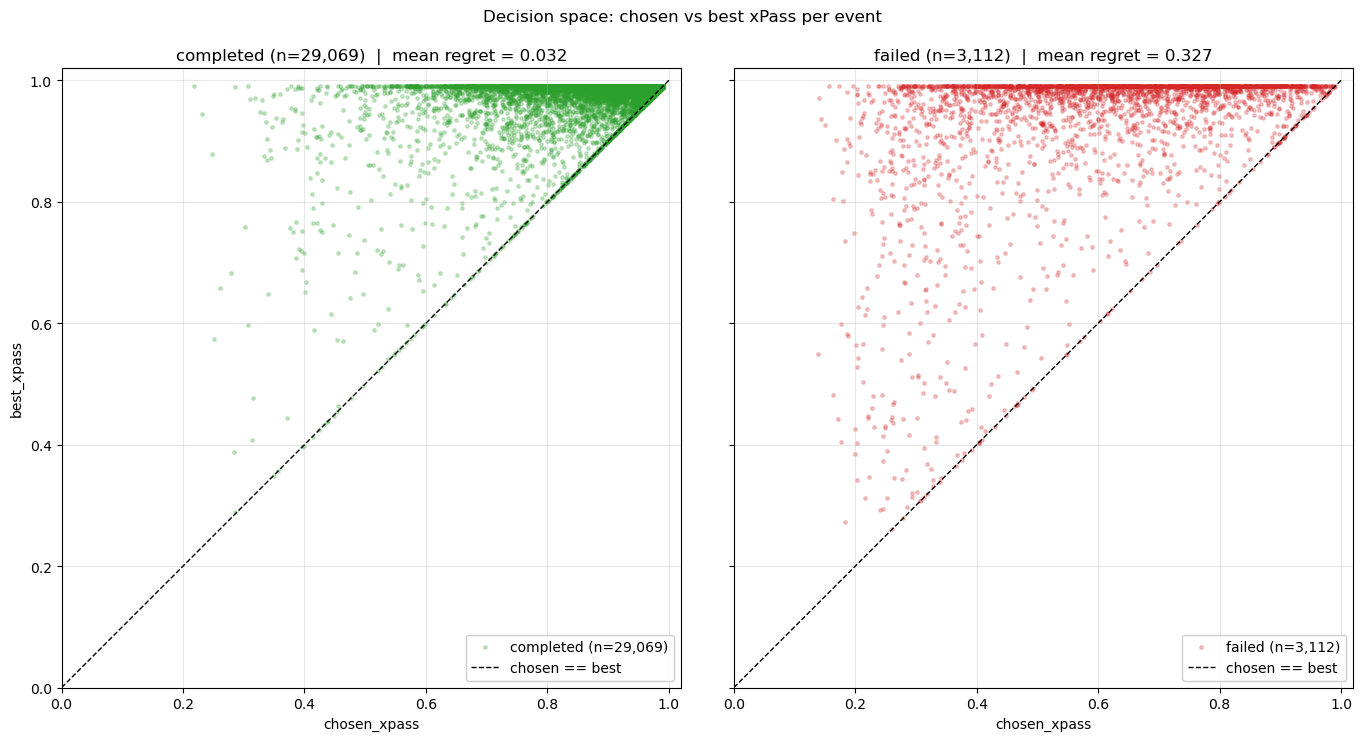

In [34]:
import matplotlib.pyplot as plt

merged_eo = per_event.join(outcome_lookup, how='inner')
completed = merged_eo[merged_eo['pass_complete'] == 1]
failed    = merged_eo[merged_eo['pass_complete'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)

for ax, df, color, label in (
    (axes[0], completed, '#2ca02c', f'completed (n={len(completed):,})'),
    (axes[1], failed,    '#d62728', f'failed (n={len(failed):,})')):
    ax.scatter(df['chosen_xpass'], df['best_xpass'],
               s=6, alpha=0.25, color=color, label=label)
    ax.plot([0, 1], [0, 1], '--', color='black', lw=1.0,
            label='chosen == best')
    ax.set_xlabel('chosen_xpass')
    ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02); ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    mean_regret = (df['best_xpass'] - df['chosen_xpass']).mean()
    ax.set_title(f'{label}  |  mean regret = {mean_regret:.3f}')
    ax.legend(loc='lower right', framealpha=0.95)
axes[0].set_ylabel('best_xpass')
fig.suptitle('Decision space: chosen vs best xPass per event', y=1.02)
plt.tight_layout(); plt.show();


### 8.7 Player-level regret leaderboard (outfield, ≥ 135 min)

Aggregated per player with the same filters used in H1:

* **Goalkeepers excluded** 
* **Minimum 135 minutes played** (`cfg.ANALYSIS_MIN_MINUTES`) so each player has at least ~1.5 full matches of evidence.

The top of the "low-regret" list should be filled with central defenders and defensive midfielders (their job is clean distribution); the top of "high-regret" should be wingers, attacking midfielders, and forwards (their job is to attempt riskier passes that create chances).


In [35]:
totals = pd.read_csv(cfg.TOTALS_CSV)
totals['macro_role'] = totals['primary_role'].apply(cfg.map_role)

# Outfield only + minutes filter (same convention as H1)
outfield = totals[(totals['macro_role'] != 'GK') &
                  (totals['minutes_played'] >= cfg.ANALYSIS_MIN_MINUTES)]
elig_keys = set(zip(outfield['player'], outfield['team']))

player_lookup = (dq_corpus_fr[['event_id', 'player', 'team']]
                 .drop_duplicates('event_id').set_index('event_id'))

player_regret = (per_event.join(player_lookup, how='inner')
                 .groupby(['player', 'team'])
                 .agg(n_passes=('regret', 'size'),
                      mean_regret=('regret', 'mean'),
                      median_regret=('regret', 'median'),
                      mean_chosen=('chosen_xpass', 'mean'),
                      mean_best=('best_xpass', 'mean')))

# Keep only outfielders with >= 135 min
player_regret = player_regret.loc[
    [k for k in player_regret.index if k in elig_keys]].round(3)

# Attach role for context
role_map_lookup = outfield.set_index(['player', 'team'])['macro_role']
player_regret['role'] = role_map_lookup
player_regret = player_regret[
    ['role', 'n_passes', 'mean_regret', 'median_regret',
     'mean_chosen', 'mean_best']]

print(f'eligible outfielders (>= {cfg.ANALYSIS_MIN_MINUTES} min) : '
      f'{len(player_regret):,}')
print()
print('=== TOP 15 LOWEST mean regret (cleanest decisions) ===')
print(player_regret.sort_values('mean_regret').head(15).to_string())
print()
print('=== TOP 15 HIGHEST mean regret (most ambitious / risky) ===')
print(player_regret.sort_values('mean_regret', ascending=False).head(15).to_string())


eligible outfielders (>= 135 min) : 272

=== TOP 15 LOWEST mean regret (cleanest decisions) ===
                                         role  n_passes  mean_regret  median_regret  mean_chosen  mean_best
player                       team                                                                          
Jan Vertonghen               Belgium       CB       146        0.005            0.0        0.985      0.990
Nikola Milenković            Serbia        CB       149        0.006            0.0        0.983      0.989
Paweł Dawidowicz             Poland        CB        55        0.010            0.0        0.978      0.988
Philipp Lienhart             Austria       CB        71        0.010            0.0        0.976      0.986
Kléper Laveran Lima Ferreira Portugal      CB       303        0.011            0.0        0.978      0.990
Virgil van Dijk              Netherlands   CB       222        0.012            0.0        0.976      0.988
Marc Guehi                   England    

## Section 9 — Rare / edge-case situations

Quick audit of unusual events to verify the corpus does not silently
contain pathological cases. Each block below counts how many rows fall
in a given regime and prints a few examples for sanity-check.

The categories are picked because they sit at the boundary of one of
the H2 filters or because they could break the model's assumptions:

* **Borderline pass-into-space (6 m < `chosen_teammate_dist_m` ≤ 12 m)**
  — kept in the corpus by the 12 m filter but where the chosen-target
  identification is least reliable. If the model behaves anomalously
  on these, we may want to tighten the filter.
* **Very long passes (`pass_distance` ≥ 40 m)** — long balls; the model
  has fewer training examples in this regime.
* **Wide-open receiver (`min_dist_def_to_receiver` ≥ 20 m)** — unusual
  configurations, often clearances or back-passes to free defenders.
* **Open lane (`min_perp_dist_to_line` = 20 m sentinel)** — no defender
  projects onto the pass segment.
* **Heavy sender pressure (`sender_pressure_count_25` ≥ 4)** — very
  contested possession; rare.
* **Lofted passes (Low or High)** — minority class (~12 % of the corpus).


In [36]:
import pandas as pd

# Use the corpus with frames so we have chosen_teammate_dist_m available
rare_df = dq_corpus_fr.copy()

regimes = [
    ('borderline pass-into-space (6m < chosen_dist <= 12m)',
        (rare_df['chosen_teammate_dist_m'] > 6) & 
        (rare_df['chosen_teammate_dist_m'] <= cfg.PASS_INTO_SPACE_M)),
    ('very long pass (>= 40 m)',
        feat['pass_distance'] >= 40),
    ('wide-open receiver (min_dist_def_to_receiver >= 20 m)',
        feat['min_dist_def_to_receiver'] >= 20),
    ('open lane (no defender on segment, sentinel = 20)',
        feat['min_perp_dist_to_line'] == 20.0),
    ('heavy sender pressure (>= 4 opp @ 2.5m)',
        feat['sender_pressure_count_25'] >= 4),
    ('lofted pass (Low or High)',
        (feat['pass_height_low'] == 1) | (feat['pass_height_high'] == 1)),
]

summary = []
for label, mask in regimes:
    n = int(mask.sum())
    share = n / len(mask) * 100
    if 'chosen_dist' in label:
        comp = rare_df.loc[mask, 'pass_complete'].mean()
    else:
        comp = feat.loc[mask, 'pass_complete'].mean()
    summary.append({'regime': label, 'n_events': n,
                    'share_of_corpus': f'{share:.2f}%',
                    'completion_rate': f'{comp:.1%}'})
pd.DataFrame(summary)

,regime,n_events,share_of_corpus,completion_rate
0,borderline pass-into-space (6m < chosen_dist <...,6723,20.89%,77.7%
1,very long pass (>= 40 m),189,0.59%,57.7%
2,wide-open receiver (min_dist_def_to_receiver >...,396,1.23%,97.7%
3,"open lane (no defender on segment, sentinel = 20)",1011,3.14%,96.1%
4,heavy sender pressure (>= 4 opp @ 2.5m),4,0.01%,75.0%
5,lofted pass (Low or High),3729,11.59%,54.4%


**A few example events from each regime** (top 3 per category, picked
deterministically). Use these to spot-check that the geometry of the
chosen pass actually fits the regime label.


In [37]:
for label, mask in regimes:
    if 'chosen_dist' in label:
        sub = rare_df.loc[mask].head(3)
        cols = ['event_id', 'player', 'team', 'minute',
                'pass_height', 'pass_complete', 'chosen_teammate_dist_m']
    else:
        sub = feat.loc[mask].head(3)
        cols = ['event_id', 'pass_distance', 'min_dist_def_to_receiver',
                'min_perp_dist_to_line', 'sender_pressure_count_25',
                'pass_complete']
    cols = [c for c in cols if c in sub.columns]
    print(f'\n=== {label} ===')
    print(sub[cols].to_string(index=False))


=== borderline pass-into-space (6m < chosen_dist <= 12m) ===
                            event_id          player        team  minute pass_height  pass_complete  chosen_teammate_dist_m
ebd4a407-65c5-42ed-a733-b9aba052326f  Stefan de Vrij Netherlands       0 Ground Pass              1                7.852640
40a75106-d185-4b64-8de3-850713b251f9 Kieran Trippier     England       1 Ground Pass              1                6.602967
da07daee-c086-4214-9c32-93718ba31705 Jude Bellingham     England       1 Ground Pass              0                9.175655

=== very long pass (>= 40 m) ===
                            event_id  pass_distance  min_dist_def_to_receiver  min_perp_dist_to_line  sender_pressure_count_25  pass_complete
8a920161-a913-4ce5-be61-9d6ae7466469      56.016054                  2.726585               0.317315                         0              0
bb91995c-b4aa-486c-9ba1-3f034406d652      46.554797                  8.782054               2.661050                        

**Visual check on the borderline pass-into-space group** — these
are the events where the chosen-target identification is least reliable.
Pitch view of three of them to confirm the geometry looks right.



=== borderline pass-into-space (6m < chosen_dist <= 12m) ===
                            event_id          player        team  minute pass_height  pass_complete  chosen_teammate_dist_m
ebd4a407-65c5-42ed-a733-b9aba052326f  Stefan de Vrij Netherlands       0 Ground Pass              1                7.852640
40a75106-d185-4b64-8de3-850713b251f9 Kieran Trippier     England       1 Ground Pass              1                6.602967
da07daee-c086-4214-9c32-93718ba31705 Jude Bellingham     England       1 Ground Pass              0                9.175655


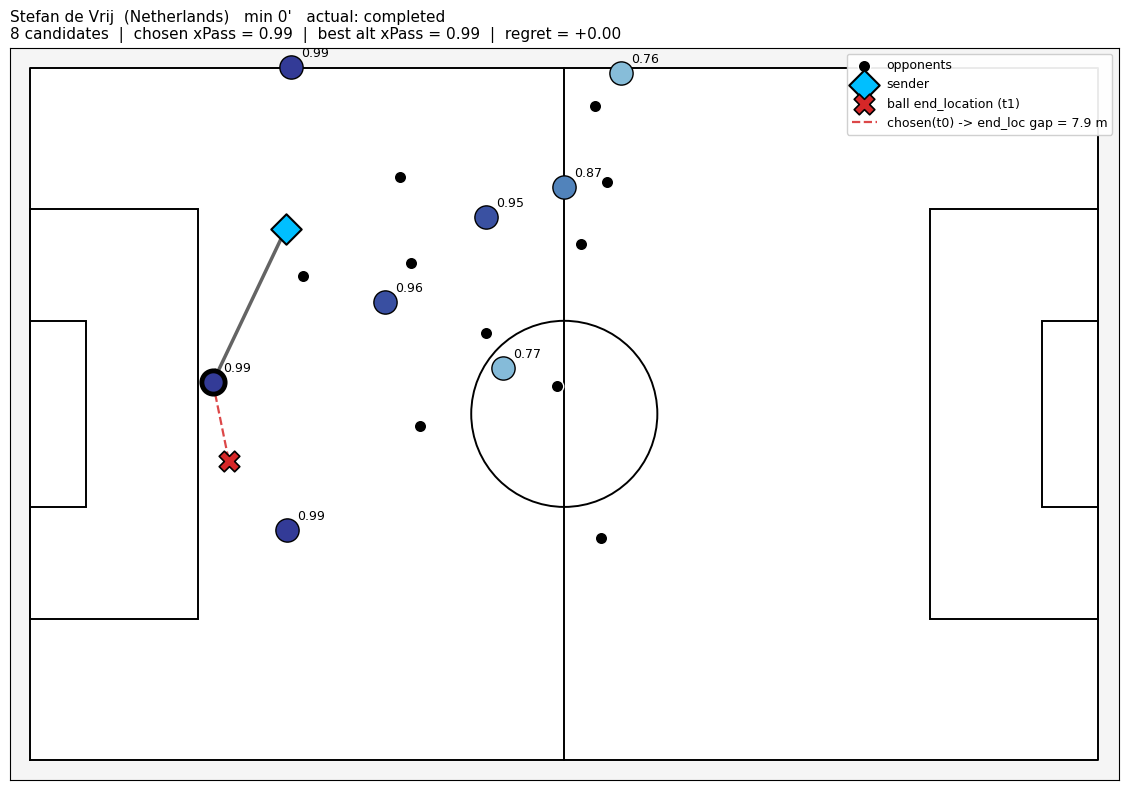


=== very long pass (>= 40 m) ===
                            event_id  pass_distance  min_dist_def_to_receiver  min_perp_dist_to_line  sender_pressure_count_25  pass_complete
8a920161-a913-4ce5-be61-9d6ae7466469      56.016054                  2.726585               0.317315                         0              0
bb91995c-b4aa-486c-9ba1-3f034406d652      46.554797                  8.782054               2.661050                         0              0
0db3f8a3-894a-4bcb-82c9-185ec7560afd      52.347677                 14.960281               0.276249                         0              1


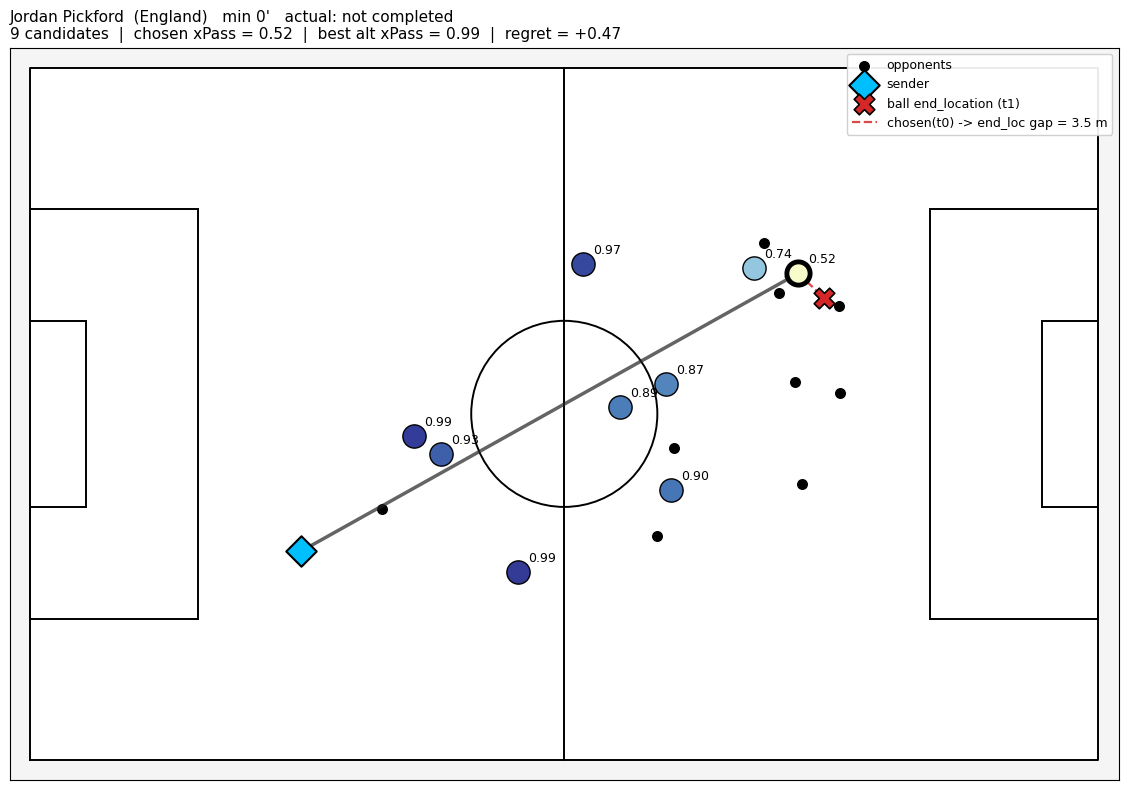


=== wide-open receiver (min_dist_def_to_receiver >= 20 m) ===
                            event_id  pass_distance  min_dist_def_to_receiver  min_perp_dist_to_line  sender_pressure_count_25  pass_complete
020f26c4-345d-44fc-b8f0-fafb2292de56      30.780157                 20.457672               3.087516                         0              1
71b75eb0-c54e-4992-844f-4f06ec8a0b70      10.125115                 20.239404              20.000000                         0              1
1b9416ab-bcb7-4fbe-800f-c1a8977ace6b      27.446190                 20.961587               6.129764                         0              1


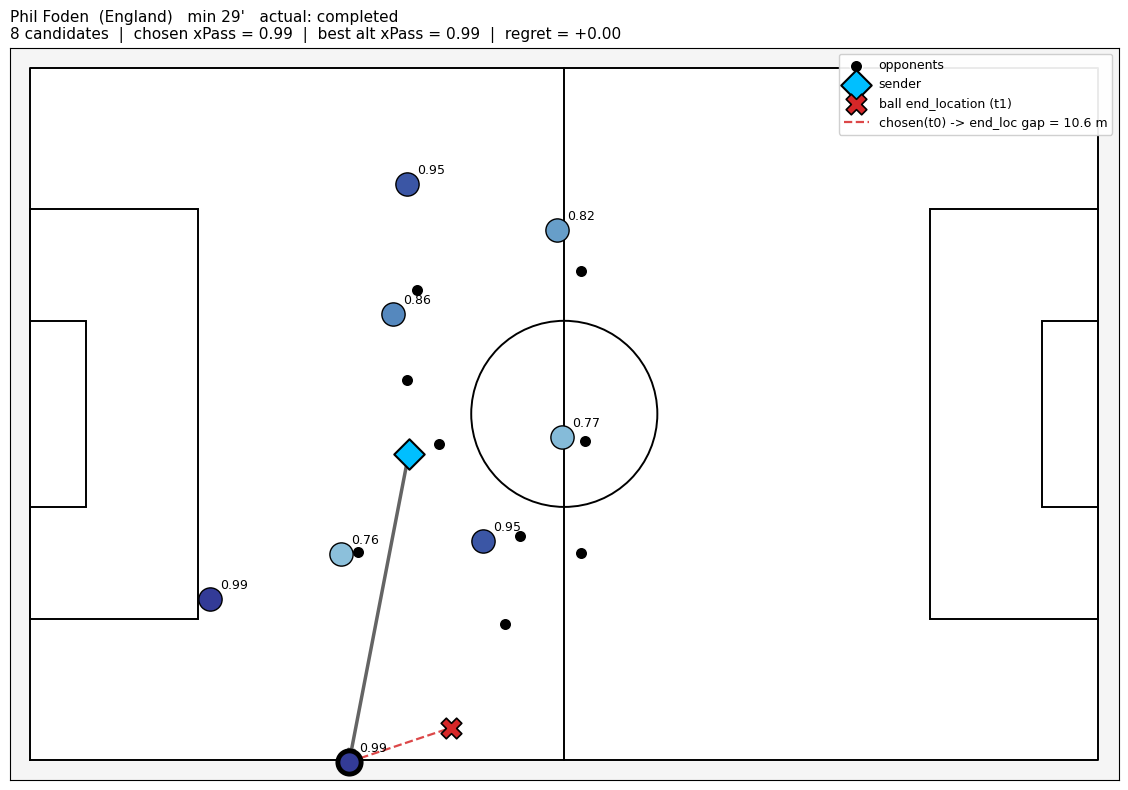


=== open lane (no defender on segment, sentinel = 20) ===
                            event_id  pass_distance  min_dist_def_to_receiver  min_perp_dist_to_line  sender_pressure_count_25  pass_complete
889a4b9c-84e8-4a5f-9711-722a30ad6ec4       4.253187                  5.656957                   20.0                         0              1
0522fe81-dfe1-4c69-b5e1-46f71c8535d2       5.507944                  8.158834                   20.0                         0              1
26cac4ca-e77d-4c0c-93c8-affef3674b9c       7.346962                  9.454793                   20.0                         0              0


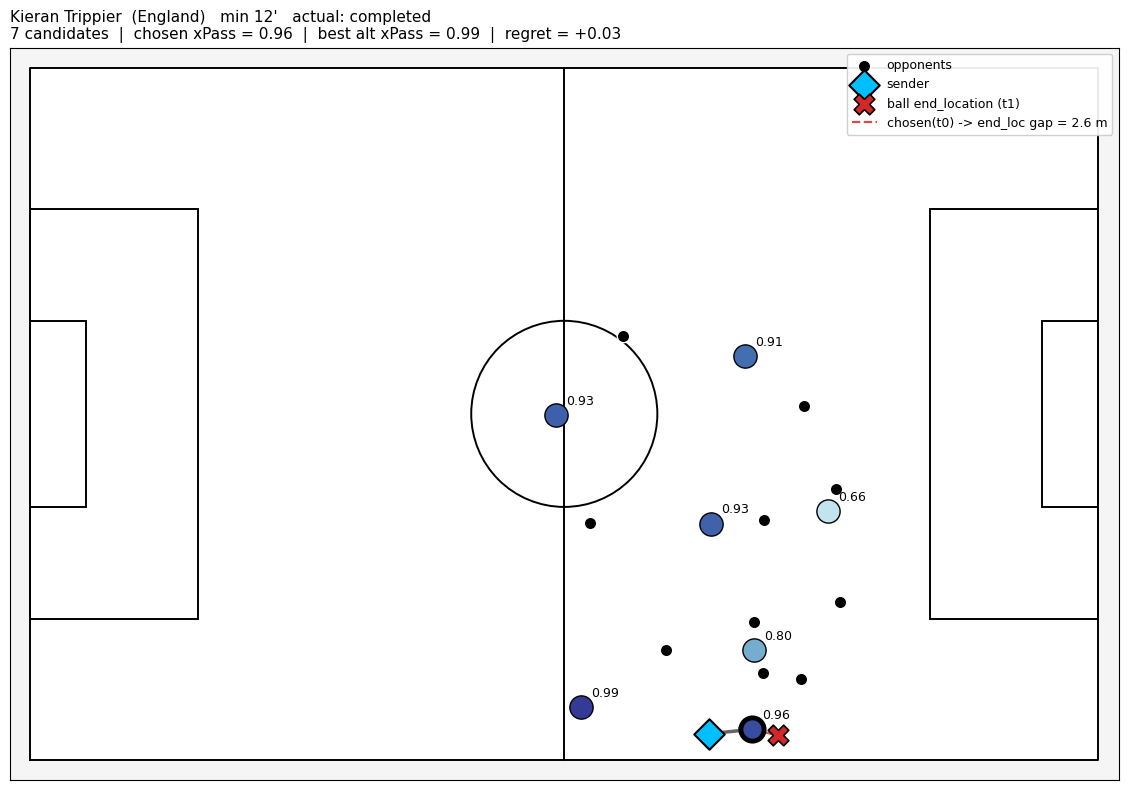


=== heavy sender pressure (>= 4 opp @ 2.5m) ===
                            event_id  pass_distance  min_dist_def_to_receiver  min_perp_dist_to_line  sender_pressure_count_25  pass_complete
c84f1ab0-2797-46f0-896e-da7e688c25e8       6.947040                  1.160452               0.073914                         4              1
b3b058c0-3733-4609-84ea-63abedcbf446      10.028057                  1.826037               0.230150                         4              1
13cbf872-65b6-4eb4-a974-61ffafa1b901       6.953365                  1.774455               0.047111                         4              0


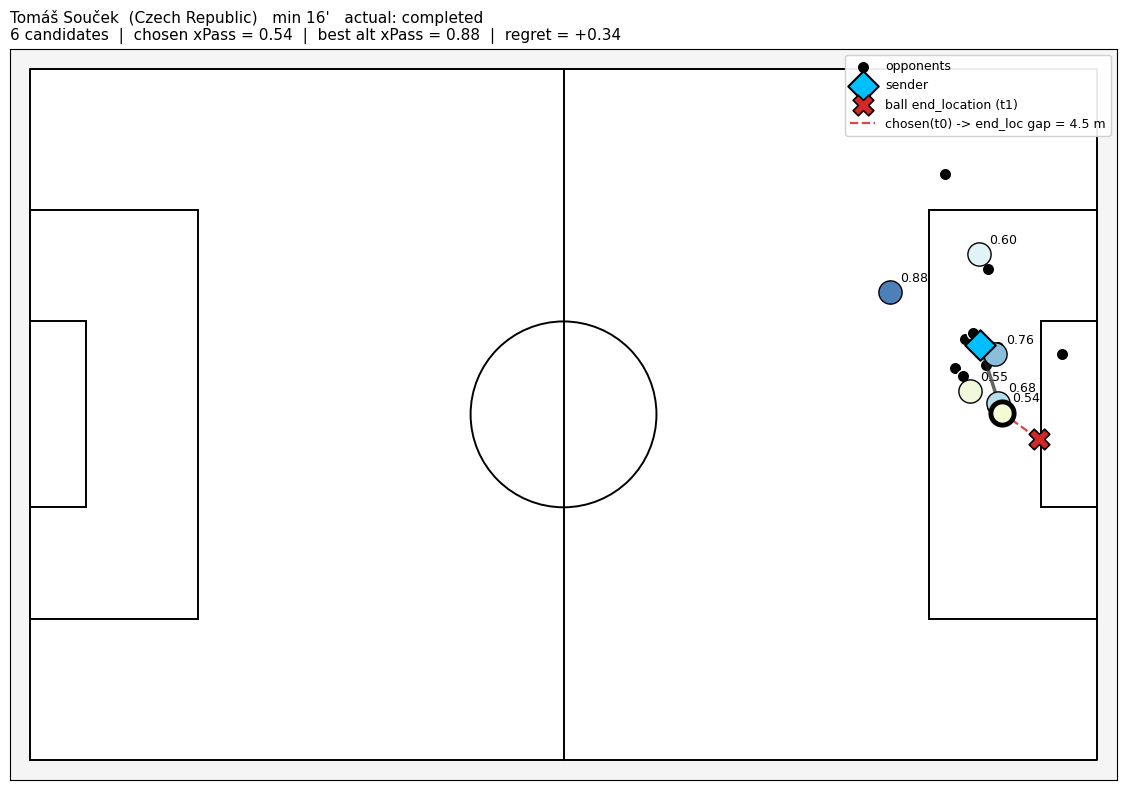


=== lofted pass (Low or High) ===
                            event_id  pass_distance  min_dist_def_to_receiver  min_perp_dist_to_line  sender_pressure_count_25  pass_complete
8a920161-a913-4ce5-be61-9d6ae7466469      56.016054                  2.726585               0.317315                         0              0
b9922678-ab29-435e-96ae-e320e1d39bf5      17.495745                 14.699593               4.411737                         0              1
c156ee23-191c-44cd-9e51-17466846e60e      18.472633                  1.398449               0.133059                         0              0


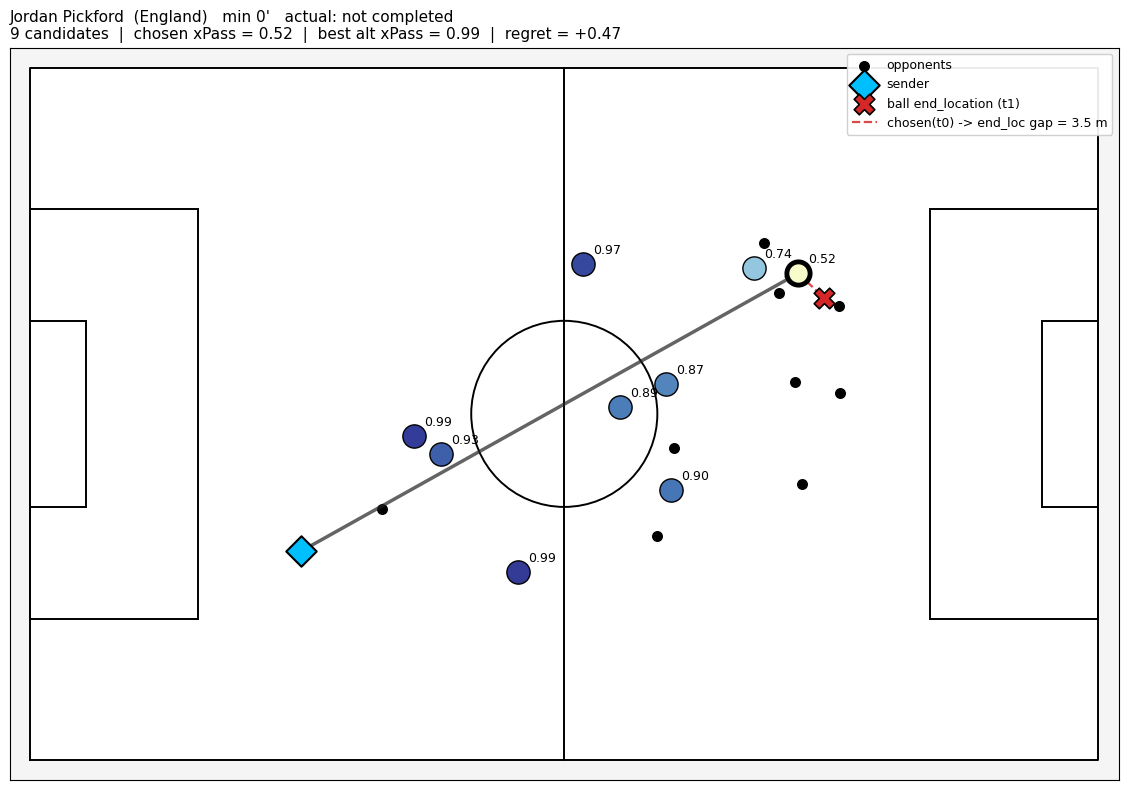

In [38]:
for label, mask in regimes:
    if 'chosen_dist' in label:
        sub = rare_df.loc[mask].head(3)
        cols = ['event_id', 'player', 'team', 'minute',
                'pass_height', 'pass_complete', 'chosen_teammate_dist_m']
    else:
        sub = feat.loc[mask].head(3)
        cols = ['event_id', 'pass_distance', 'min_dist_def_to_receiver',
                'min_perp_dist_to_line', 'sender_pressure_count_25',
                'pass_complete']
    cols = [c for c in cols if c in sub.columns]
    print(f'\n=== {label} ===')
    print(sub[cols].to_string(index=False))

    try:
        first_ev_id = sub['event_id'].iloc[0]
        fig = viz.plot_pass_alternatives(first_ev_id, alts, dq_corpus_fr)
        plt.show()
    except IndexError:
        print(f"Nessun evento trovato per il regime: {label}")

---

## Outputs and next step

Files written by this notebook (under `Decision_Quality/data/`):

* **`dq_corpus.csv`** — H2 working corpus, 32,181 events (29,069 completed + 3,112 failed) after H1 → header / pass-into-space / frame filters.
* **`xpass_features.parquet`** — table of the 13 model columns (12 logical features + Low/High one-hot) plus the 4 diagnostic columns kept for segmentation.
* **`xpass_model_gbm_beta.joblib`** — calibrated production model: `HistGradientBoostingClassifier` + Beta calibrator + clip [0.05, 0.99]. Loaded in §6.
* **`xpass_model_logit.joblib`**, `xpass_model_gbm.joblib` — uncalibrated baseline / GBM models, kept for comparison and reproducibility.
* **`alternatives.parquet`** — long-form table with one row per (event × candidate teammate); ~231k rows. Each row carries the 13 features computed for that hypothetical target plus the calibrated xPass score. Built in §8.
* **`cache/frames360_cache.parquet`**, **`cache/pass_meta_cache.parquet`** — raw StatsBomb 360 frames and pass metadata; gitignored.

Three xPass model variants were compared head-to-head in §5 (`logit`, `logit_balanced`, `gbm`); `gbm` won on AUC and log-loss and was promoted to production after Beta calibration in §5.4.

**Next step (still inside H2)** — `alternatives.parquet` is the input scaffold for the xEPV / Decision Quality index, where every alternative target is evaluated by combining its xPass with the EPV grid via
`xEPV(target) = xPass · EPV(target) − (1−xPass) · EPV(105−target_x, target_y)`.
The chosen-vs-best comparison in xEPV space yields the per-event regret metric `regret_xEPV`, which feeds the player-level Decision Quality leaderboard. 